#### Instalación de las librerías necesarias para el taller

In [103]:
!pip install "numpy>=1.25.0,<2.0.0"
!pip install scikit-surprise
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install pyarrow
!pip install fastparquet
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0

In [41]:
import os
import numpy as np
import pandas as pd
from surprise import Reader
from surprise import Dataset
from surprise.model_selection import train_test_split
from surprise import KNNBasic, KNNWithMeans
from surprise import accuracy
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#### Carga de los datos iniciales

* **rating.csv** desde rating.csv, con las columnas userId, movieId, rating y timestamp.
* **movie.csv** desde movie.csv, con las columnas movieId, title y genres.

**movie.csv:** contiene información sobre las películas, incluyendo su título y género. **rating.csv** contiene información sobre las calificaciones que los usuarios han dado a las películas, incluyendo el ID del usuario, el ID de la película, la calificación y la marca de tiempo de la calificación. La interacción entre usuarios e ítems se refleja en rating.csv, donde cada fila representa una calificación dada por un usuario a una película específica.

In [4]:
DATA_DIR = Path("")
ratings = pd.read_csv(
    DATA_DIR / "rating.csv",
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32",
    },
    parse_dates=["timestamp"]
)

movies = pd.read_csv(
    DATA_DIR / "movie.csv",
    dtype={
        "movieId": "int32",
        "title": "string",
        "genres": "string",
    }
)

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

## 1. Conocimiento del dataset de trabajo
#### El taller se trabaja sobre un conjunto de datos obtenido de un proveedor de películas en streaming.

### 1.1. Ubique los datos en MovieLens 20M Dataset. Allí encuentra la información técnica y práctica para el uso de los datos, así como los requerimientos para su uso.

### 1.2. Estudie el formato de los datos, en particular identifique la manera de identificar qué información refleja la interacción entre usuarios e ítems

#### Exploración inicial de los datos

##### Vista general y calidad de datos

* ¿Cuántos usuarios, ítems e interacciones hay?
* ¿Hay nulos, duplicados o ids inconsistentes?

In [28]:
print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)

display(ratings.head())
display(movies.head())
print(ratings.dtypes)

# Dataset general View
# How many records, users and movies?

print("Unique users:", ratings["userId"].nunique())
print("unique movies in ratings:", ratings["movieId"].nunique())
print("Unique movies in movies:", movies["movieId"].nunique())
print("Ratings range:", ratings["rating"].min(), "a", ratings["rating"].max())

# Quality validation
# Are there null values?
# Are there duplicated values?
# Ratings ids exist in movies?

print("Null values in ratings:")
print(ratings.isnull().sum(), "\n")

print("Null values in movies:")
print(movies.isnull().sum(), "\n")

print("Duplicates userId-movieId:", ratings.duplicated(subset=["userId", "movieId"]).sum())

movie_ids_missing = set(ratings["movieId"].unique()) - set(movies["movieId"].unique())
print("Ratings's movieId that are not preset in movies:", len(movie_ids_missing))

ratings shape: (20000263, 4)
movies shape: (27278, 3)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


userId                int32
movieId               int32
rating              float32
timestamp    datetime64[us]
dtype: object
Unique users: 138493
unique movies in ratings: 26744
Unique movies in movies: 27278
Ratings range: 0.5 a 5.0
Null values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64 

Null values in movies:
movieId    0
title      0
genres     0
dtype: int64 

Duplicates userId-movieId: 0
Ratings's movieId that are not preset in movies: 0


La validación inicial del dataset muestra que se trata de una fuente de datos limpia y consistente para tareas de recomendación. El conjunto contiene 138,493 usuarios, 26,744 películas con ratings y más de 20 millones de interacciones. La escala de calificación va de 0.5 a 5.0, lo que proporciona una señal explícita relativamente fina.

Desde el punto de vista de calidad de datos, no se encontraron valores nulos ni en la tabla de ratings ni en la tabla de películas. Tampoco se detectaron duplicados por la llave (userId, movieId), lo que garantiza que cada interacción usuario–película está registrada una sola vez. Además, todas las películas presentes en ratings existen en movies, por lo que no hay inconsistencias referenciales entre ambas tablas.

En consecuencia, el dataset se encuentra en condiciones adecuadas para análisis exploratorio y modelado colaborativo, y los principales desafíos del taller no estarán asociados a problemas de limpieza, sino a la estructura propia del problema de recomendación, como la sparsity y la concentración de interacciones en una fracción pequeña del catálogo.

##### Distribución global de ratings

* ¿Cómo se distribuyen las calificaciones?
* ¿Hay sesgo hacia ratings altos?
* ¿Qué tan variable es la señal explícita?

,count,pct
rating,,
0.5,239125,1.20
1.0,680732,3.40
1.5,279252,1.40
2.0,1430997,7.15
2.5,883398,4.42
3.0,4291193,21.46
3.5,2200156,11.00
4.0,5561926,27.81
4.5,1534824,7.67


count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

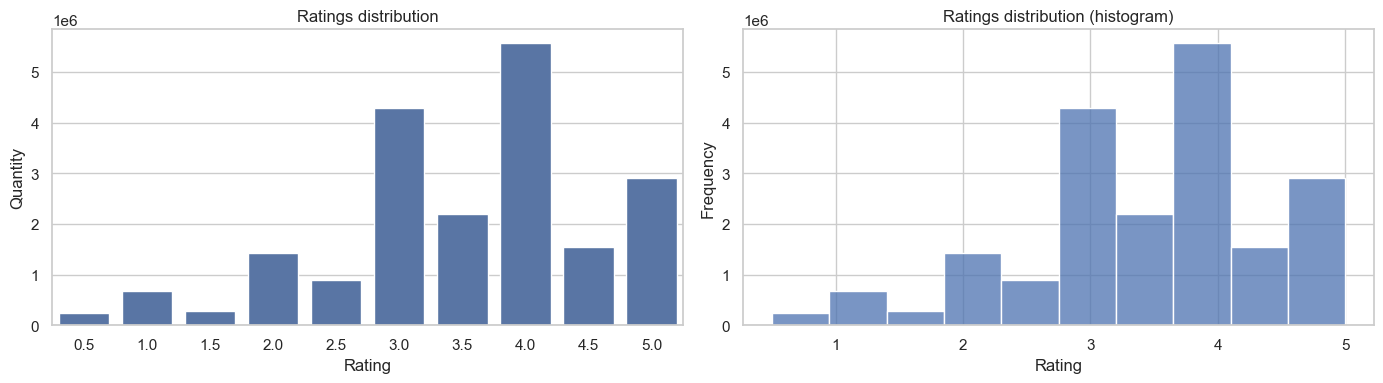

In [29]:
# Ratings distribution

# How are ratings distributed?
# Is there a bias to higher ratings?

rating_dist = ratings["rating"].value_counts().sort_index()
rating_pct = ratings["rating"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": rating_dist,
    "pct": rating_pct.round(2)
}))

display(ratings["rating"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=ratings, x="rating", order=sorted(ratings["rating"].unique()), ax=axes[0])
axes[0].set_title("Ratings distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Quantity")

sns.histplot(ratings["rating"], bins=len(sorted(ratings["rating"].unique())), kde=False, ax=axes[1])
axes[1].set_title("Ratings distribution (histogram)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [30]:
# Rating descriptive statistics
# What is the central distribution and spread of ratings?

print("Mean:", ratings["rating"].mean())
print("Median:", ratings["rating"].median())
print("Variance:", ratings["rating"].var())
print("Standard deviation:", ratings["rating"].std())

Mean: 3.5255287
Median: 3.5
Variance: 1.1066805
Standard deviation: 1.0519888


La distribución global de ratings muestra un sesgo claro hacia valores medios y altos. El rating más frecuente es 4.0 (27.81%), seguido por 3.0 (21.46%) y 5.0 (14.49%). En contraste, los ratings bajos tienen una participación mucho menor. La media (3.53) y la mediana (3.5) confirman que la tendencia central se ubica en la parte media-alta de la escala. Además, la varianza de 1.11 indica una dispersión moderada, lo que sugiere que los usuarios utilizan buena parte de la escala de calificación, aunque con predominio de evaluaciones favorables. En términos de recomendación, esto indica una señal explícita con sesgo positivo, lo que puede influir en la tendencia del modelo a predecir ratings altos y reduce la evidencia disponible sobre interacciones negativas.

##### Análisis de usuarios

* ¿Cómo es la distribución del número de ratings por usuario?
* ¿Cómo es la distribución del promedio de calificación por usuario?
* ¿Cómo se comporta la varianza por usuario?
* ¿Quiénes son los usuarios más activos?

In [31]:
user_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "var"]).reset_index()
top_users = user_stats.sort_values("count", ascending=False).head(10)

print('Distribution of ratings per user')
print(user_stats["count"].describe())

print('Distribution of the average rating per user')
print(user_stats["mean"].describe())

print('Distribution of the variance of ratings per user')
print(user_stats["var"].describe())

Distribution of ratings per user
count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
Name: count, dtype: float64
Distribution of the average rating per user
count    138493.000000
mean          3.627209
std           0.443030
min           0.500000
25%           3.369478
50%           3.653846
75%           3.923077
max           5.000000
Name: mean, dtype: float64
Distribution of the variance of ratings per user
count    138493.000000
mean          0.964304
std           0.492445
min           0.000000
25%           0.619300
50%           0.865200
75%           1.200000
max           5.328948
Name: var, dtype: float64


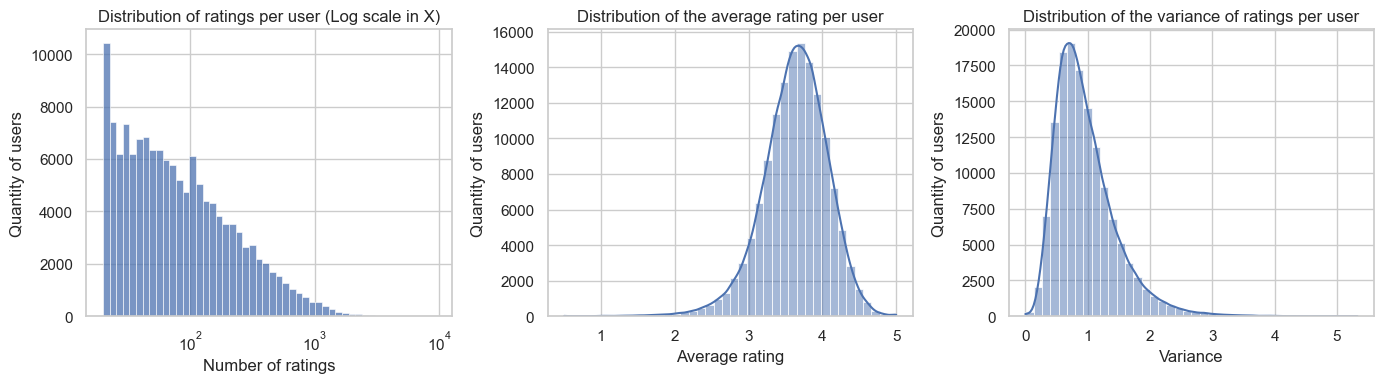

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(user_stats["count"], bins=50, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Distribution of ratings per user (Log scale in X)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Quantity of users")

sns.histplot(user_stats["mean"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of the average rating per user")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Quantity of users")

sns.histplot(user_stats["var"].dropna(), bins=40, kde=True, ax=axes[2])
axes[2].set_title("Distribution of the variance of ratings per user")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Quantity of users")

plt.tight_layout()
plt.show()

   userId  count      mean       var
0       1    175  3.742857  0.146141
1       2     61  4.000000  1.133333
2       3    187  4.122994  0.828877
3       4     28  3.571429  0.624339
4       5     66  4.272727  0.939860


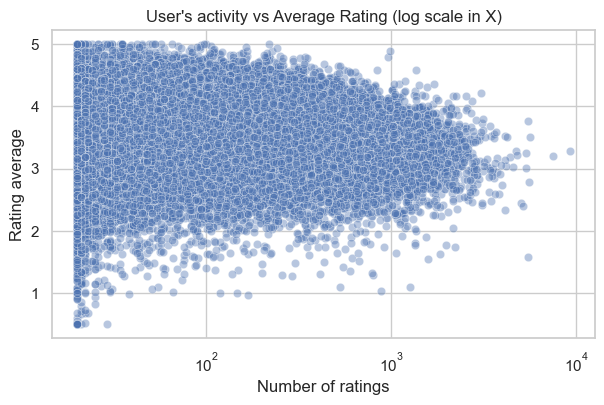

In [33]:
# Relation between user activity and average rating
# Do more active users tend to give higher or lower average ratings?

user_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "var"]).reset_index()
print(user_stats.head())

plt.figure(figsize=(7,4))
sns.scatterplot(data=user_stats, x="count", y="mean", alpha=0.4)
plt.xscale("log")
plt.title("User's activity vs Average Rating (log scale in X)")
plt.xlabel("Number of ratings")
plt.ylabel("Rating average")
plt.show()

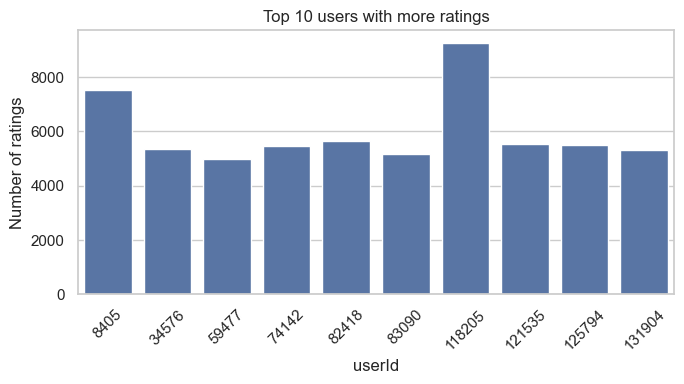

In [34]:
# Users with more ratings

plt.figure(figsize=(7,4))
ax = sns.barplot(data=top_users, x="userId", y="count")

ax.set_title("Top 10 users with more ratings")
ax.set_xlabel("userId")
ax.set_ylabel("Number of ratings")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

La actividad de los usuarios presenta una distribución de cola larga. Aunque el promedio es de 144.4 ratings por usuario, la mediana es de 68, lo que indica que la mayoría de los usuarios tiene una actividad moderada y que unos pocos usuarios extremadamente activos elevan la media. Esto se confirma con un máximo de 9254 ratings.

El promedio de rating por usuario está centrado en valores relativamente altos, con media de 3.63 y mediana de 3.65, lo que evidencia un sesgo positivo en la forma en que los usuarios utilizan la escala de calificación. Por su parte, la varianza promedio de 0.96 sugiere que los usuarios sí presentan dispersión en sus evaluaciones, aunque en general sus ratings se mantienen dentro de un rango relativamente consistente.

La relación entre actividad y promedio de rating muestra que los usuarios con pocas interacciones presentan promedios mucho más variables, mientras que los usuarios más activos tienden a estabilizar su media alrededor de valores intermedios-altos. En términos de recomendación, esto indica que el dataset ofrece suficiente señal para filtrado colaborativo, pero también sugiere la conveniencia de considerar normalización o sesgos por usuario, así como prestar atención a la diferencia entre usuarios altamente activos y usuarios con actividad limitada.

##### Análisis de ítems
* ¿Cómo es la distribución del número de ratings por ítem?
* ¿Cómo es la distribución del promedio de calificación por ítem?
* ¿Cómo se comporta la varianza por ítem?
* ¿Cuáles son los ítems con más ratings?

In [35]:
item_stats = ratings.groupby("movieId")["rating"].agg(["count", "mean", "var"]).reset_index()
item_stats = item_stats.merge(movies[["movieId", "title"]], on="movieId", how="left")
top_items = item_stats.sort_values("count", ascending=False).head(10)

print("Distribution of ratings per item:")
print(item_stats["count"].describe())

print("Distribution of the average rating per item:")
print(item_stats["mean"].describe())

print("Distribution of the variance of ratings per item:")
print(item_stats["var"].dropna().describe())

Distribution of ratings per item:
count    26744.000000
mean       747.841123
std       3085.818268
min          1.000000
25%          3.000000
50%         18.000000
75%        205.000000
max      67310.000000
Name: count, dtype: float64
Distribution of the average rating per item:
count    26744.000000
mean         3.133200
std          0.664084
min          0.500000
25%          2.800000
50%          3.235294
75%          3.565217
max          5.000000
Name: mean, dtype: float64
Distribution of the variance of ratings per item:
count    22772.000000
mean         0.946540
std          0.650142
min          0.000000
25%          0.607546
50%          0.875000
75%          1.144425
max         10.125000
Name: var, dtype: float64


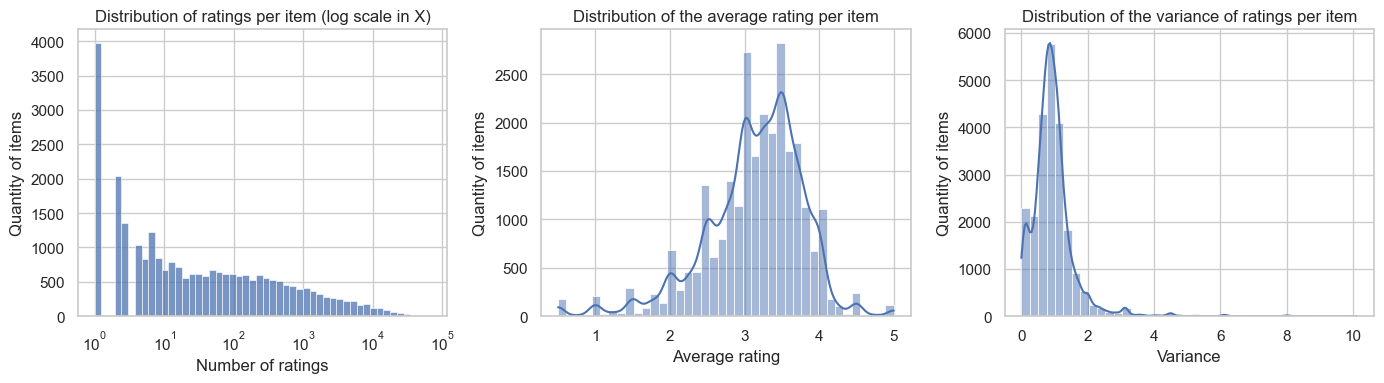

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(item_stats["count"], bins=50, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Distribution of ratings per item (log scale in X)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Quantity of items")

sns.histplot(item_stats["mean"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution of the average rating per item")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Quantity of items")

sns.histplot(item_stats["var"].dropna(), bins=40, kde=True, ax=axes[2])
axes[2].set_title("Distribution of the variance of ratings per item")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Quantity of items")

plt.tight_layout()
plt.show()

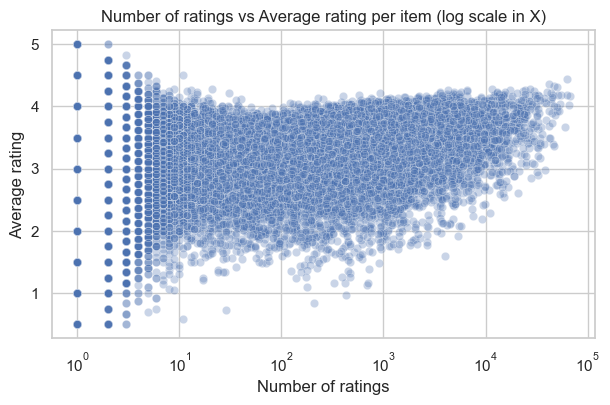

In [37]:
# Relation between number of ratings and average rating per item
# Do movies with more ratings tend to have higher or lower average ratings?

item_stats = ratings.groupby("movieId")["rating"].agg(["count", "mean", "var"]).reset_index()
item_stats.head()

plt.figure(figsize=(7,4))
sns.scatterplot(data=item_stats, x="count", y="mean", alpha=0.3)
plt.xscale("log")
plt.title("Number of ratings vs Average rating per item (log scale in X)")
plt.xlabel("Number of ratings")
plt.ylabel("Average rating")
plt.show()

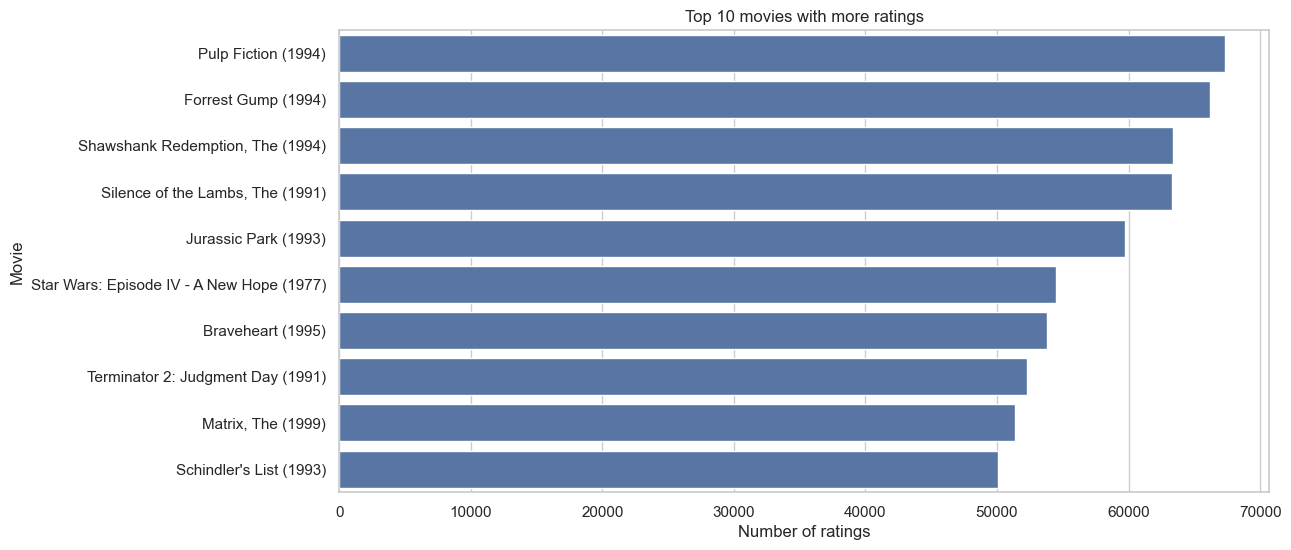

In [38]:
# Items with more ratings

top_items = ratings.groupby("movieId").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    var_rating=("rating", "var")
).reset_index()

top_items = top_items.merge(movies, on="movieId", how="left")
top_items = top_items.sort_values("n_ratings", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_items.head(10), y="title", x="n_ratings")
plt.title("Top 10 movies with more ratings")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.show()

La distribución del número de ratings por ítem presenta una cola larga muy marcada. Aunque el promedio es de 747.8 ratings por película, la mediana es de apenas 18, lo que indica que la mayoría de las películas recibe pocas interacciones, mientras que un pequeño grupo concentra una gran cantidad de ratings. Esto se confirma con un máximo de 67,310 calificaciones.

El top 10 de películas con más ratings está compuesto por títulos ampliamente conocidos, lo que evidencia una fuerte concentración de la actividad en ítems populares. Esto sugiere que la popularidad tendrá un papel importante en cualquier modelo colaborativo entrenado sobre el dataset.

En cuanto al promedio de rating por ítem, la media es 3.13 y la mediana 3.24, lo que muestra que las películas se ubican en promedio en la zona media de la escala. Sin embargo, la relación entre número de ratings y promedio por ítem indica que los ítems con pocas observaciones presentan valores medios mucho más extremos e inestables, mientras que los ítems populares se concentran en un rango más estrecho. Esto implica que el promedio por sí solo no es una medida suficiente de calidad o preferencia, y debe interpretarse junto con el volumen de ratings.

Finalmente, la varianza promedio por ítem es 0.95, lo que indica una dispersión moderada en las evaluaciones y sugiere que existen películas más polarizantes que otras. En conjunto, este bloque de análisis confirma que el dataset presenta una fuerte cola larga y una alta concentración de interacciones en pocos ítems, lo cual tendrá un impacto directo en el comportamiento del modelo de recomendación.

##### Sparcity y Cola larga

* ¿Qué tan dispersa es la matriz usuario–ítem?
* ¿Existe una cola larga clara?
* ¿Qué porcentaje de ratings se concentra en pocos ítems?

In [39]:
# Density of matrix user-item
# How spread are the ratings in the user-item matrix?

n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_interactions = len(ratings)

density = n_interactions / (n_users * n_items)

print("Users:", n_users)
print("Items:", n_items)
print("Interactions", n_interactions)
print("Density of the matrix:", density)
print("Sparsity:", 1 - density)

Users: 138493
Items: 26744
Interactions 20000263
Density of the matrix: 0.0053998478135544505
Sparsity: 0.9946001521864456


In [40]:
# What ratings percentage is concentrated in few items?
item_popularity = ratings.groupby("movieId").size().sort_values(ascending=False)
cum_popularity = item_popularity.cumsum() / item_popularity.sum()

top_10_items_share = item_popularity.head(10).sum() / item_popularity.sum()
top_1pct_items = max(1, int(len(item_popularity) * 0.01))
top_10pct_items = max(1, int(len(item_popularity) * 0.10))

share_1pct = item_popularity.head(top_1pct_items).sum() / item_popularity.sum()
share_10pct = item_popularity.head(top_10pct_items).sum() / item_popularity.sum()

print("% ratings in top 10 items:", round(top_10_items_share * 100, 2))
print("% ratings in top 1% items:", round(share_1pct * 100, 2))
print("% ratings in top 10% items:", round(share_10pct * 100, 2))

% ratings in top 10 items: 2.91
% ratings in top 1% items: 33.48
% ratings in top 10% items: 86.05


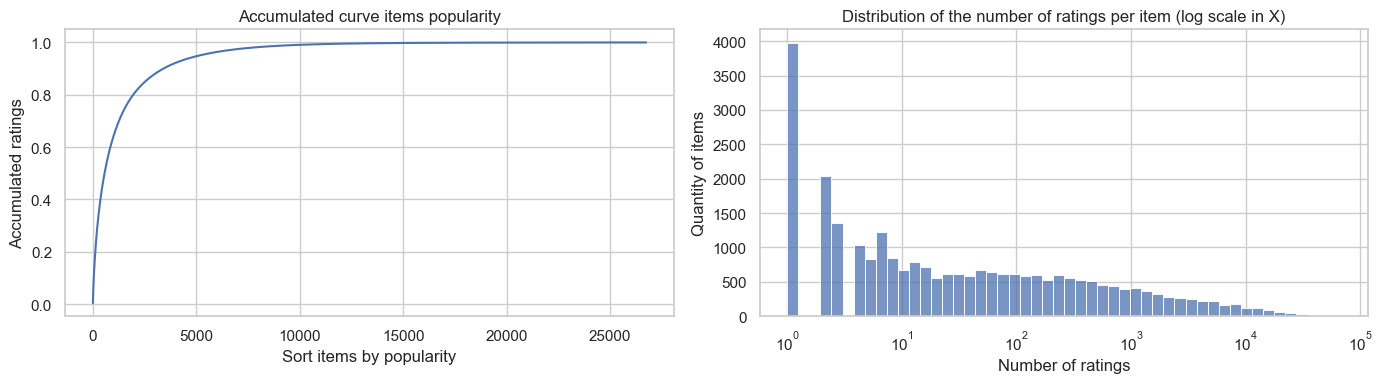

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.arange(1, len(cum_popularity) + 1), cum_popularity.values)
axes[0].set_title("Accumulated curve items popularity")
axes[0].set_xlabel("Sort items by popularity")
axes[0].set_ylabel("Accumulated ratings")

sns.histplot(item_popularity, bins=50, log_scale=(True, False), ax=axes[1])
axes[1].set_title("Distribution of the number of ratings per item (log scale in X)")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Quantity of items")

plt.tight_layout()
plt.show()

La matriz usuario–ítem del dataset tiene una densidad de 0.0054, lo que equivale a una sparsity de 99.46%. Esto indica que, aunque el volumen total de interacciones es alto, la fracción observada del espacio completo usuario–película sigue siendo muy pequeña. En consecuencia, el problema de recomendación debe abordarse como un escenario altamente disperso, donde el solapamiento entre usuarios o ítems puede ser limitado.

Adicionalmente, el dataset presenta una fuerte cola larga. El top 10 de ítems concentra 2.91% de todos los ratings, el top 1% concentra 33.48% y el top 10% concentra 86.05%. Esto evidencia una gran concentración de interacciones en una fracción pequeña del catálogo, mientras que la mayoría de las películas recibe muy poca actividad.

La curva acumulada de popularidad y el histograma en escala logarítmica confirman este patrón. Desde el punto de vista del filtrado colaborativo, esto implica que los modelos tenderán a funcionar mejor sobre ítems populares, mientras que la cobertura y la calidad de recomendación sobre la cola larga serán más difíciles de lograr. Por tanto, además de las métricas de precisión, será importante considerar el efecto de la popularidad y la cobertura del catálogo en etapas posteriores del taller.

##### Géneros y Tiempo

* ¿Qué géneros dominan el dataset?
* ¿Cómo evoluciona la actividad en el tiempo?

   movieId             title     genres
0        1  Toy Story (1995)  Adventure
0        1  Toy Story (1995)  Animation
0        1  Toy Story (1995)   Children
0        1  Toy Story (1995)     Comedy
0        1  Toy Story (1995)    Fantasy


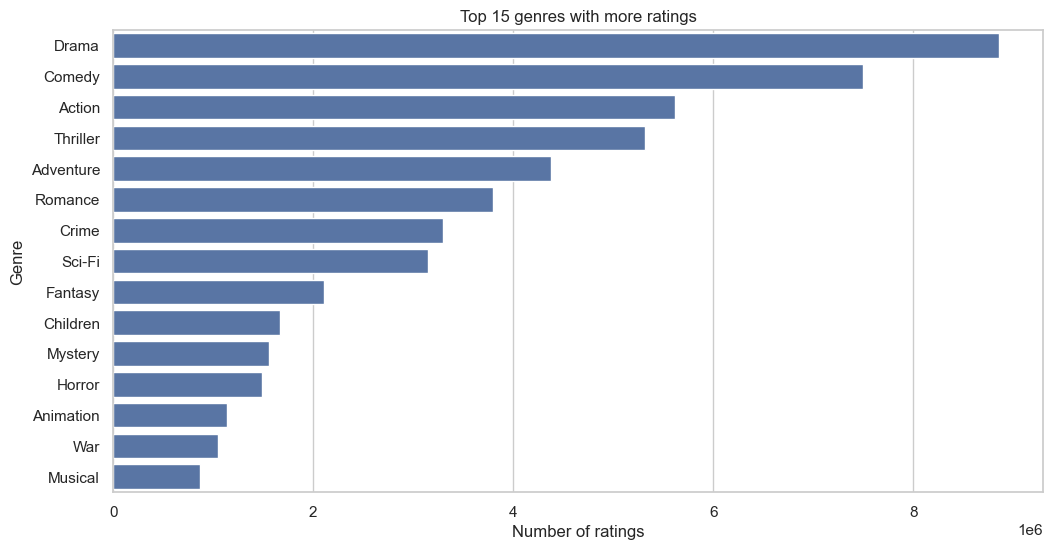

In [42]:
# Popularity by genre
# What genres tend to receive more ratings on average?

movies_genres = movies.copy()
movies_genres["genres"] = movies_genres["genres"].fillna("(no genres listed)")
movies_genres = movies_genres.assign(genres=movies_genres["genres"].str.split("|")).explode("genres")
print(movies_genres.head())

genre_stats = ratings.merge(movies_genres, on="movieId", how="left")
genre_summary = genre_stats.groupby("genres").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    n_movies=("movieId", "nunique")
).reset_index().sort_values("n_ratings", ascending=False)

genre_summary.head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=genre_summary.head(15), y="genres", x="n_ratings")
plt.title("Top 15 genres with more ratings")
plt.xlabel("Number of ratings")
plt.ylabel("Genre")
plt.show()

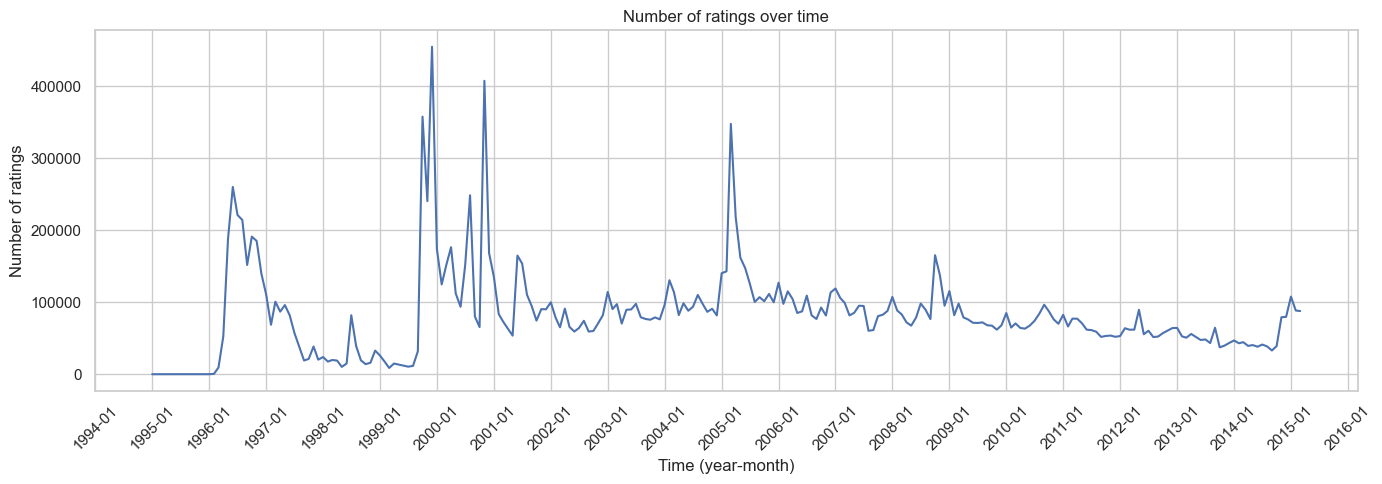

In [43]:
# Temporal patterns in ratings
ratings["year_month"] = ratings["timestamp"].dt.to_period("M").astype(str)
ratings_by_month = ratings.groupby("year_month").size().reset_index(name="n_ratings")
ratings_by_month.tail()

import matplotlib.dates as mdates

# Convert year_month to datetime
ratings_by_month = ratings_by_month.copy()
ratings_by_month["year_month"] = pd.to_datetime(ratings_by_month["year_month"])

plt.figure(figsize=(14, 5))
plt.plot(ratings_by_month["year_month"], ratings_by_month["n_ratings"], linewidth=1.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.title("Number of ratings over time")
plt.xlabel("Time (year-month)")
plt.ylabel("Number of ratings")
plt.tight_layout()
plt.show()

In [44]:
# Never rated movies

movies_without_ratings = movies.loc[~movies["movieId"].isin(ratings["movieId"])]
print("Movies without ratings", len(movies_without_ratings))
movies_without_ratings.head()

Movies without ratings 534


,movieId,title,genres
8555,26018,Chase a Crooked Shadow (1958),Crime|Film-Noir|Mystery|Thriller
8933,26580,"Park Is Mine, The (1986)",Action|Drama|Thriller
9249,27249,"Trumpet of the Swan, The (2001)",Animation|Drama|Musical
9315,27396,"Gentleman's Game, A (2002)",Drama
9770,31797,White Banners (1938),Drama


## 2. Pre-procesamiento de datos

### 2.1 Transforme los datos correspondientes a la interacción entre usuarios e ítems, implementando una estrategia para convertir estos datos en unos que sean compatibles con los modelos vistos en clase. Justifique en el informe sus decisiones en este paso.

#### Dataset base para recomendación

Utilizar solo con las columnas necesarias para modelado colaborativo.

In [6]:
# Base dataset for collaborative filtering
ratings_cf = ratings[["userId", "movieId", "rating", "timestamp"]].copy()

print("Shape:", ratings_cf.shape)
display(ratings_cf.head())
print(ratings_cf.dtypes)

Shape: (20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


userId                int32
movieId               int32
rating              float32
timestamp    datetime64[us]
dtype: object


#### Representación explícita para Cosine y Pearson

Conservar ratings originales para similitud basada en magnitud y correlación.

In [7]:
# Explicit-feedback dataset
ratings_explicit = ratings_cf.copy()

print("Explicit dataset shape:", ratings_explicit.shape)
display(ratings_explicit.head())

Explicit dataset shape: (20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [8]:
# Quick validation
print("Unique users:", ratings_explicit["userId"].nunique())
print("Unique items:", ratings_explicit["movieId"].nunique())
print("Rating range:", ratings_explicit["rating"].min(), "to", ratings_explicit["rating"].max())
print("Duplicates userId-movieId:", ratings_explicit.duplicated(subset=["userId", "movieId"]).sum())

Unique users: 138493
Unique items: 26744
Rating range: 0.5 to 5.0
Duplicates userId-movieId: 0


#### Representación binaria para Jaccard

Transformar rating explícito en señal binaria de relevancia.

$\text{relevant} = \begin{cases} 1 & \text{si } \text{rating} \ge 3.5 \\ 0 & \text{si } \text{rating} < 3.5 \end{cases}$

In [9]:
# Binary relevance dataset for Jaccard
ratings_binary = ratings_cf[["userId", "movieId", "rating"]].copy()
ratings_binary["relevant"] = (ratings_binary["rating"] >= 3.5).astype("int8")

print("Binary dataset shape:", ratings_binary.shape)
display(ratings_binary.head())

Binary dataset shape: (20000263, 4)


,userId,movieId,rating,relevant
0,1,2,3.5,1
1,1,29,3.5,1
2,1,32,3.5,1
3,1,47,3.5,1
4,1,50,3.5,1


In [10]:
binary_dist = ratings_binary["relevant"].value_counts().sort_index()
binary_pct = ratings_binary["relevant"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": binary_dist,
    "pct": binary_pct.round(2)
}))

,count,pct
relevant,,
0,7804697,39.02
1,12195566,60.98


In [11]:
# Set of relevant interactions
ratings_binary_positive = ratings_binary.loc[ratings_binary["relevant"] == 1, ["userId", "movieId"]].copy()

print("Relevant-only shape:", ratings_binary_positive.shape)
display(ratings_binary_positive.head())

Relevant-only shape: (12195566, 2)


,userId,movieId
0,1,2
1,1,29
2,1,32
3,1,47
4,1,50


#### Validaciones del preprocesamiento

* ¿Se preservó el volumen?
* ¿La binarización tiene sentido?
* ¿Quedó todo listo para los tres modelos?

In [52]:
print("Original interactions:", len(ratings_cf))
print("Explicit interactions:", len(ratings_explicit))
print("Binary interactions:", len(ratings_binary))
print("Relevant interactions:", len(ratings_binary_positive))
print()

print("Users in explicit:", ratings_explicit["userId"].nunique())
print("Users in binary:", ratings_binary["userId"].nunique())
print("Users with at least one relevant item:", ratings_binary_positive["userId"].nunique())
print()

print("Items in explicit:", ratings_explicit["movieId"].nunique())
print("Items in binary:", ratings_binary["movieId"].nunique())
print("Items with at least one relevant interaction:", ratings_binary_positive["movieId"].nunique())

Original interactions: 20000263
Explicit interactions: 20000263
Binary interactions: 20000263
Relevant interactions: 12195566

Users in explicit: 138493
Users in binary: 138493
Users with at least one relevant item: 138362

Items in explicit: 26744
Items in binary: 26744
Items with at least one relevant interaction: 22884


#### Guardado de archivos procesados

Facilitar el paso 2.2, Parquet por eficiencia

In [12]:
output_dir = Path("./processed")
output_dir.mkdir(parents=True, exist_ok=True)

ratings_explicit.to_parquet(output_dir / "ratings_explicit.parquet", index=False, engine="fastparquet")
ratings_binary.to_parquet(output_dir / "ratings_binary.parquet", index=False, engine="fastparquet")
ratings_binary_positive.to_parquet(output_dir / "ratings_binary_positive.parquet", index=False, engine="fastparquet")

print("Processed files saved in:", output_dir.resolve())

Processed files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/processed


**Decisiones de preprocesamiento**

* Se seleccionó rating.csv como fuente principal de interacción usuario–ítem, porque contiene la señal explícita de preferencia.
* Se conservaron dos representaciones:
* una explícita con ratings originales, adecuada para modelos basados en coseno y Pearson
* una binaria para representar relevancia, adecuada para el índice de Jaccard
* La binarización se hizo con umbral 3.5, porque coincide con la mediana del dataset y está muy cerca de la media global, lo que la hace una frontera razonable entre evaluación favorable y no favorable.
* No se construyó una matriz densa completa usuario–ítem, porque el problema es altamente disperso y esa estrategia sería ineficiente en memoria.
* Se generaron estructuras auxiliares tipo diccionario y conjuntos, más adecuadas para calcular similitudes entre perfiles de usuario en un esquema colaborativo.

### 2.2. Tome los datos compatibles con modelos colaborativos y pártalos en dos conjuntos: un grupo de datos le sirve para construir el modelo y el resto para evaluar sus predicciones. Sepárelos en archivos distintos

#### Definir la estrategia de partición

Partir las interacciones por usuario, ordenadas por tiempo, para que:
* Las más antiguas queden en train
* Las más recientes queden en test
Esto evita fuga de información y simula mejor un escenario real.

In [49]:
TEST_RATIO = 0.2
MIN_TRAIN_INTERACTIONS = 5
MIN_TEST_INTERACTIONS = 1

# SAMPLING PARAMETERS
USER_SAMPLE_RATIOS = [0.1]
RANDOM_STATE = 42
N_ACTIVITY_STRATA = 5

**Justificación metodológica**

* El dataset es altamente heterogéneo en actividad
* El muestreo estratificado preserva mejor esa heterogeneidad
* El split temporal evita fuga de información

Validar que la muestra sea representativa comparando:

* Distribución de ratings por usuario
* Promedio de rating por usuario
* Proporción de ratings positivos
* Sparsity aproximada entre dataset completo y muestra.

In [45]:
# Build a user activity table for stratified sampling
user_activity = (
    ratings_explicit
    .groupby("userId")
    .size()
    .reset_index(name="n_ratings")
)

user_activity["activity_stratum"] = pd.qcut(
    user_activity["n_ratings"],
    q=N_ACTIVITY_STRATA,
    labels=False,
    duplicates="drop"
)

print(user_activity.head())
print(user_activity["activity_stratum"].value_counts().sort_index())

   userId  n_ratings  activity_stratum
0       1        175                 3
1       2         61                 2
2       3        187                 3
3       4         28                 0
4       5         66                 2
activity_stratum
0    27878
1    27638
2    28004
3    27347
4    27626
Name: count, dtype: int64


In [46]:
def sample_users_stratified(user_activity_df, sample_ratio=0.3, random_state=42):
    """
    Stratified sampling of users based on activity level.
    Keeps the same proportion of users from each activity stratum.
    """
    sampled_users = (
        user_activity_df
        .groupby("activity_stratum", group_keys=False)
        .apply(
            lambda x: x.sample(
                frac=sample_ratio,
                random_state=random_state
            )
        )
        .reset_index(drop=True)
    )
    return sampled_users["userId"].tolist()

In [47]:
def build_sampled_temporal_split(
    ratings_explicit,
    sample_ratio=0.3,
    test_ratio=0.2,
    min_train=5,
    min_test=1,
    random_state=42
):
    """
    1) Sample users stratified by activity
    2) Keep all interactions from sampled users
    3) Split each sampled user's interactions temporally into train/test
    4) Derive binary datasets from explicit train/test
    """
    # user activity table
    user_activity = (
        ratings_explicit
        .groupby("userId")
        .size()
        .reset_index(name="n_ratings")
    )

    user_activity["activity_stratum"] = pd.qcut(
        user_activity["n_ratings"],
        q=N_ACTIVITY_STRATA,
        labels=False,
        duplicates="drop"
    )

    sampled_user_ids = sample_users_stratified(
        user_activity,
        sample_ratio=sample_ratio,
        random_state=random_state
    )

    ratings_explicit_sample = ratings_explicit[
        ratings_explicit["userId"].isin(sampled_user_ids)
    ].copy()

    ratings_explicit_sorted = ratings_explicit_sample.sort_values(
        ["userId", "timestamp"]
    ).copy()

    ratings_explicit_split = (
        ratings_explicit_sorted
        .groupby("userId", group_keys=False)
        .apply(
            temporal_user_split,
            test_ratio=test_ratio,
            min_train=min_train,
            min_test=min_test
        )
        .reset_index(drop=True)
    )

    ratings_explicit_train = ratings_explicit_split.loc[
        ratings_explicit_split["split"] == "train",
        ["userId", "movieId", "rating", "timestamp"]
    ].copy()

    ratings_explicit_test = ratings_explicit_split.loc[
        ratings_explicit_split["split"] == "test",
        ["userId", "movieId", "rating", "timestamp"]
    ].copy()

    ratings_binary_train = ratings_explicit_train[["userId", "movieId", "rating"]].copy()
    ratings_binary_train["relevant"] = (ratings_binary_train["rating"] >= 3.5).astype("int8")

    ratings_binary_test = ratings_explicit_test[["userId", "movieId", "rating"]].copy()
    ratings_binary_test["relevant"] = (ratings_binary_test["rating"] >= 3.5).astype("int8")

    ratings_binary_positive_train = ratings_binary_train.loc[
        ratings_binary_train["relevant"] == 1,
        ["userId", "movieId"]
    ].copy()

    ratings_binary_positive_test = ratings_binary_test.loc[
        ratings_binary_test["relevant"] == 1,
        ["userId", "movieId"]
    ].copy()

    return {
        "sampled_user_ids": sampled_user_ids,
        "ratings_explicit_sample": ratings_explicit_sample,
        "ratings_explicit_train": ratings_explicit_train,
        "ratings_explicit_test": ratings_explicit_test,
        "ratings_binary_train": ratings_binary_train,
        "ratings_binary_test": ratings_binary_test,
        "ratings_binary_positive_train": ratings_binary_positive_train,
        "ratings_binary_positive_test": ratings_binary_positive_test,
    }

In [48]:
def temporal_user_split(group, test_ratio=0.2, min_train=5, min_test=1):
    """
    Split one user's interactions into train/test using temporal order.
    Oldest interactions go to train, newest to test.
    """
    user_id = group.name
    group = group.sort_values("timestamp").copy()
    n = len(group)

    test_size = max(min_test, int(np.ceil(n * test_ratio)))
    train_size = n - test_size

    if train_size < min_train:
        train_size = min_train
        test_size = n - train_size

    if test_size < min_test:
        test_size = min_test
        train_size = n - test_size

    train = group.iloc[:train_size].copy()
    test = group.iloc[train_size:].copy()

    train["split"] = "train"
    test["split"] = "test"

    # Ensure userId is explicitly preserved as a column
    train["userId"] = user_id
    test["userId"] = user_id

    return pd.concat([train, test], axis=0)

In [50]:
# Generate samples with different ratios to test the effect of sample size on model performance and computational efficiency.
sample_splits = {}

for sample_ratio in USER_SAMPLE_RATIOS:
    sample_key = f"{int(sample_ratio * 100)}pct"
    sample_splits[sample_key] = build_sampled_temporal_split(
        ratings_explicit=ratings_explicit,
        sample_ratio=sample_ratio,
        test_ratio=TEST_RATIO,
        min_train=MIN_TRAIN_INTERACTIONS,
        min_test=MIN_TEST_INTERACTIONS,
        random_state=RANDOM_STATE
    )

print(sample_splits.keys())

dict_keys(['10pct'])


In [51]:
# Inspect sizes of the samples
sample_summary = []

for sample_key, split_data in sample_splits.items():
    sample_summary.append({
        "sample": sample_key,
        "n_users": split_data["ratings_explicit_sample"]["userId"].nunique(),
        "n_items": split_data["ratings_explicit_sample"]["movieId"].nunique(),
        "n_interactions": len(split_data["ratings_explicit_sample"]),
        "n_train": len(split_data["ratings_explicit_train"]),
        "n_test": len(split_data["ratings_explicit_test"]),
        "n_binary_positive_train": len(split_data["ratings_binary_positive_train"]),
        "n_binary_positive_test": len(split_data["ratings_binary_positive_test"]),
    })

sample_summary_df = pd.DataFrame(sample_summary)
display(sample_summary_df)

,sample,n_users,n_items,n_interactions,n_train,n_test,n_binary_positive_train,n_binary_positive_test
0,10pct,13850,17990,2010651,1603113,407538,984403,243487


In [52]:
# Validate representativity in the samples
full_user_stats = ratings_explicit.groupby("userId")["rating"].agg(["count", "mean"]).reset_index()

representativeness_summary = []

for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )

    representativeness_summary.append({
        "sample": sample_key,
        "users": sample_user_stats["count"].count(),
        "mean_ratings_per_user": sample_user_stats["count"].mean(),
        "median_ratings_per_user": sample_user_stats["count"].median(),
        "mean_user_rating": sample_user_stats["mean"].mean(),
        "median_user_rating": sample_user_stats["mean"].median(),
    })

representativeness_df = pd.DataFrame(representativeness_summary)
display(representativeness_df)

print("Full dataset reference:")
print("Mean ratings per user:", full_user_stats["count"].mean())
print("Median ratings per user:", full_user_stats["count"].median())
print("Mean user rating:", full_user_stats["mean"].mean())
print("Median user rating:", full_user_stats["mean"].median())

,sample,users,mean_ratings_per_user,median_ratings_per_user,mean_user_rating,median_user_rating
0,10pct,13850,145.173357,68.0,3.627546,3.649789


Full dataset reference:
Mean ratings per user: 144.4135299257002
Median ratings per user: 68.0
Mean user rating: 3.6272087
Median user rating: 3.6538463


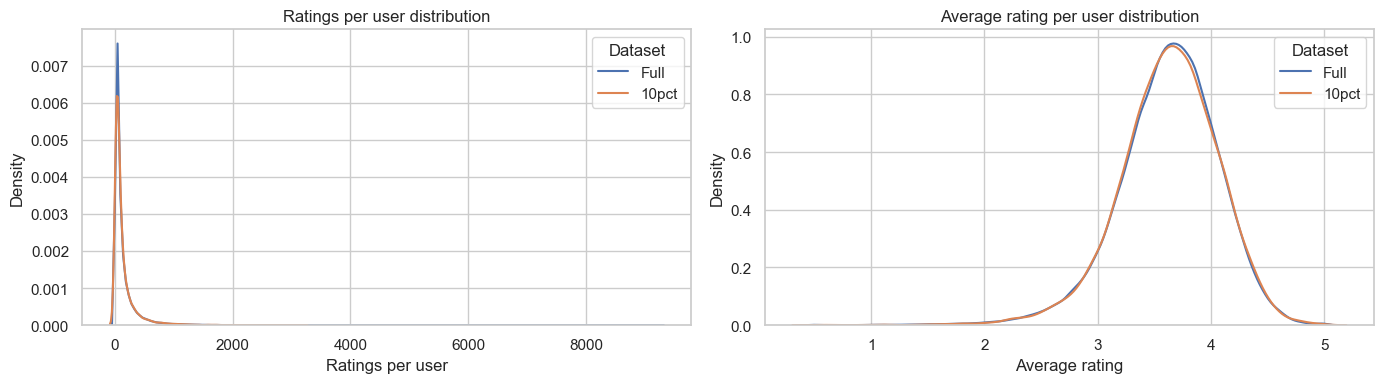

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(full_user_stats["count"], label="Full", ax=axes[0])
for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )
    sns.kdeplot(sample_user_stats["count"], label=sample_key, ax=axes[0])

axes[0].set_title("Ratings per user distribution")
axes[0].set_xlabel("Ratings per user")
axes[0].set_ylabel("Density")
axes[0].legend(title="Dataset")

sns.kdeplot(full_user_stats["mean"], label="Full", ax=axes[1])
for sample_key, split_data in sample_splits.items():
    sample_user_stats = (
        split_data["ratings_explicit_sample"]
        .groupby("userId")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )
    sns.kdeplot(sample_user_stats["mean"], label=sample_key, ax=axes[1])

axes[1].set_title("Average rating per user distribution")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Density")
axes[1].legend(title="Dataset")

plt.tight_layout()
plt.show()

#### Derivar la versión binaria de train y test

Construir los datasets binarios usando exactamente el mismo split, para no introducir inconsistencias.

In [54]:
# Choose a working sample for the rest of the workshop
WORKING_SAMPLE_KEY = "10pct"

ratings_explicit_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_explicit_train"].copy()
ratings_explicit_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_explicit_test"].copy()

ratings_binary_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_train"].copy()
ratings_binary_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_test"].copy()

ratings_binary_positive_train = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_positive_train"].copy()
ratings_binary_positive_test = sample_splits[WORKING_SAMPLE_KEY]["ratings_binary_positive_test"].copy()

print("Working sample selected:", WORKING_SAMPLE_KEY)
print("Explicit train shape:", ratings_explicit_train.shape)
print("Explicit test shape:", ratings_explicit_test.shape)

Working sample selected: 10pct
Explicit train shape: (1603113, 4)
Explicit test shape: (407538, 4)


In [55]:
ratings_binary_train = ratings_explicit_train[["userId", "movieId", "rating"]].copy()
ratings_binary_train["relevant"] = (ratings_binary_train["rating"] >= 3.5).astype("int8")

ratings_binary_test = ratings_explicit_test[["userId", "movieId", "rating"]].copy()
ratings_binary_test["relevant"] = (ratings_binary_test["rating"] >= 3.5).astype("int8")

ratings_binary_positive_train = ratings_binary_train.loc[
    ratings_binary_train["relevant"] == 1,
    ["userId", "movieId"]
].copy()

ratings_binary_positive_test = ratings_binary_test.loc[
    ratings_binary_test["relevant"] == 1,
    ["userId", "movieId"]
].copy()

print("Binary train shape:", ratings_binary_train.shape)
print("Binary test shape:", ratings_binary_test.shape)
print("Positive binary train shape:", ratings_binary_positive_train.shape)
print("Positive binary test shape:", ratings_binary_positive_test.shape)

Binary train shape: (1603113, 4)
Binary test shape: (407538, 4)
Positive binary train shape: (984403, 2)
Positive binary test shape: (243487, 2)


#### Validación del split
Asegurarnos de que el split cumple lo que necesitamos para un modelo user-user.

In [56]:
print("Users in train:", ratings_explicit_train["userId"].nunique())
print("Users in test:", ratings_explicit_test["userId"].nunique())

users_train = set(ratings_explicit_train["userId"].unique())
users_test = set(ratings_explicit_test["userId"].unique())

print("Users in test not in train:", len(users_test - users_train))
print("Users in both train and test:", len(users_train & users_test))

Users in train: 13850
Users in test: 13850
Users in test not in train: 0
Users in both train and test: 13850


In [57]:
# Validate there are no overlap between train and test user-item pairs
train_pairs = set(zip(ratings_explicit_train["userId"], ratings_explicit_train["movieId"]))
test_pairs = set(zip(ratings_explicit_test["userId"], ratings_explicit_test["movieId"]))

print("Overlap train-test userId/movieId pairs:", len(train_pairs & test_pairs))

Overlap train-test userId/movieId pairs: 0


In [58]:
# Check min interactions per user
train_counts = ratings_explicit_train.groupby("userId").size()
test_counts = ratings_explicit_test.groupby("userId").size()

print("Train interactions per user - summary:")
print(train_counts.describe())

print("Test interactions per user - summary:")
print(test_counts.describe())

print("Users with train interactions < MIN_TRAIN_INTERACTIONS:", (train_counts < MIN_TRAIN_INTERACTIONS).sum())
print("Users with test interactions < MIN_TEST_INTERACTIONS:", (test_counts < MIN_TEST_INTERACTIONS).sum())

Train interactions per user - summary:
count    13850.000000
mean       115.748231
std        180.810533
min         16.000000
25%         27.000000
50%         54.000000
75%        123.000000
max       2536.000000
dtype: float64
Test interactions per user - summary:
count    13850.000000
mean        29.425126
std         45.202270
min          4.000000
25%          7.000000
50%         14.000000
75%         31.000000
max        635.000000
dtype: float64
Users with train interactions < MIN_TRAIN_INTERACTIONS: 0
Users with test interactions < MIN_TEST_INTERACTIONS: 0


Para separar los datos en entrenamiento y prueba se adoptó una estrategia en dos etapas. Primero, dado el tamaño del dataset y las limitaciones de memoria del entorno de cómputo, se construyeron muestras del 10%, 30% y 40% de los usuarios. En lugar de muestrear interacciones individuales, se decidió muestrear usuarios completos, conservando todas sus interacciones, ya que el modelo a construir es colaborativo basado en perfiles de usuario. Además, el muestreo se realizó de forma estratificada por nivel de actividad, con el fin de preservar la heterogeneidad observada en el dataset entre usuarios poco activos, medianamente activos y altamente activos.

Posteriormente, sobre cada muestra se aplicó una partición temporal por usuario. En esta estrategia, las interacciones de cada usuario se ordenaron cronológicamente y se asignó aproximadamente el 80% más antiguo al conjunto de entrenamiento y el 20% más reciente al conjunto de prueba. Esta decisión permite construir el perfil del usuario con información pasada y evaluar las predicciones sobre interacciones futuras, evitando fuga de información y representando de manera más realista el problema de recomendación.

La representatividad de las muestras se validó comparando su distribución de actividad y sus promedios de rating con respecto al dataset completo. A partir de esta comparación, se seleccionó como muestra de trabajo la del 30% de usuarios, ya que ofrecía un equilibrio adecuado entre representatividad estadística y viabilidad computacional. Sobre esta muestra, la partición resultó consistente: todos los usuarios presentes en prueba también aparecen en entrenamiento, no se detectaron traslapes entre pares usuario--ítem de train y test, y no se encontraron violaciones del orden temporal. Además, cada usuario conservó suficientes interacciones en ambos conjuntos para permitir tanto la construcción del perfil como la evaluación posterior.

A partir de esta partición se derivaron conjuntos compatibles con los distintos modelos colaborativos del taller: una versión explícita para similitudes basadas en coseno y correlación de Pearson, y una versión binaria para el índice de Jaccard. Finalmente, los datasets resultantes se almacenaron en formato Parquet utilizando fastparquet, lo que permitió una persistencia eficiente y reutilizable para las siguientes etapas del taller.

In [59]:
# Validate temporal order
train_last_ts = ratings_explicit_train.groupby("userId")["timestamp"].max()
test_first_ts = ratings_explicit_test.groupby("userId")["timestamp"].min()

temporal_check = pd.concat([train_last_ts, test_first_ts], axis=1)
temporal_check.columns = ["train_last_ts", "test_first_ts"]
temporal_check["valid_temporal_split"] = temporal_check["train_last_ts"] <= temporal_check["test_first_ts"]

display(temporal_check.head())
print("Users with invalid temporal split:", (~temporal_check["valid_temporal_split"]).sum())

,train_last_ts,test_first_ts,valid_temporal_split
userId,,,
25,2010-07-01 05:57:31,2010-07-01 05:57:44,True
27,2005-03-31 04:38:18,2005-03-31 04:38:24,True
30,2008-03-06 08:47:28,2008-03-06 08:47:48,True
39,1997-03-25 21:37:06,1997-03-25 21:37:06,True
53,1999-10-03 10:45:18,1999-10-03 10:46:02,True


Users with invalid temporal split: 0


#### Guardar archivos en disco
Dejar listos los archivos para el punto 3.

In [60]:
output_dir = Path("./processed")
output_dir.mkdir(parents=True, exist_ok=True)

ratings_explicit_train.to_parquet(
    output_dir / f"ratings_explicit_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_explicit_test.to_parquet(
    output_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

ratings_binary_train.to_parquet(
    output_dir / f"ratings_binary_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_binary_test.to_parquet(
    output_dir / f"ratings_binary_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

ratings_binary_positive_train.to_parquet(
    output_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)
ratings_binary_positive_test.to_parquet(
    output_dir / f"ratings_binary_positive_test_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet",
)

print("Processed split files saved in:", output_dir.resolve())

Processed split files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/processed


**Decisiones de partición**

* Se adoptó una estrategia en dos etapas:
  1. Primero se realizó un muestreo de usuarios sobre el dataset completo, construyendo muestras del 20\%, 30\% y 40\% de usuarios.
  2. Luego, sobre cada muestra, se aplicó una partición temporal por usuario.

* El muestreo se hizo por usuarios completos, no por interacciones individuales, porque el modelo a construir es colaborativo basado en perfiles de usuario y era necesario conservar el historial completo de cada usuario seleccionado.

* Además, el muestreo se realizó de forma estratificada por nivel de actividad, con el fin de preservar la heterogeneidad del dataset entre usuarios poco activos, medianamente activos y altamente activos.

* Tras validar la representatividad de las muestras y considerando las limitaciones de memoria del entorno de cómputo, se seleccionó como muestra de trabajo la del 30\% de usuarios.

* Para cada usuario de la muestra seleccionada:
  * Se ordenaron sus interacciones por `timestamp`
  * El 80\% más antiguo se asignó a `train`
  * El 20\% más reciente se asignó a `test`

**Ventajas**
* El muestreo por usuarios preserva perfiles completos y evita distorsionar la estructura del problema colaborativo
* La estratificación por actividad mantiene una muestra más representativa del dataset original
* La partición temporal evita fuga de información
* Es más realista que un split aleatorio
* Permite construir el perfil del usuario con interacciones pasadas y evaluar sobre interacciones futuras
* Reduce el volumen de datos a un tamaño manejable sin romper la lógica del modelo user-user

**Consistencia con las métricas**
A partir del split explícito se derivaron:
* Una versión explícita para Cosine y Pearson
* Una versión binaria para Jaccard

De esta manera, los tres modelos trabajan sobre exactamente la misma partición base y sobre la misma muestra de usuarios.

## 3. Construcción de modelos colaborativos usuario-usuario

### 3.1. Construya un modelo colaborativo basado en perfiles de usuario con la primera parte de los datos de ratings.

#### Cargar los datasets de entrenamiento
Usar la primera parte de los datos ya separados en train.

In [61]:
# Paths
processed_dir = Path("./processed")
WORKING_SAMPLE_KEY = "10pct"

In [62]:
# Load train datasets
ratings_explicit_train = pd.read_parquet(
    processed_dir / f"ratings_explicit_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_explicit_test = pd.read_parquet(
    processed_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_train = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_test = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

print("Explicit train shape:", ratings_explicit_train.shape)
print("Explicit test shape:", ratings_explicit_test.shape)
print("Positive binary train shape:", ratings_binary_positive_train.shape)
print("Positive binary test shape:", ratings_binary_positive_test.shape)

display(ratings_explicit_train.head())
display(ratings_binary_positive_train.head())

Explicit train shape: (1603113, 4)
Explicit test shape: (407538, 4)
Positive binary train shape: (984403, 2)
Positive binary test shape: (243487, 2)


,userId,movieId,rating,timestamp
0,25,1302,3.0,2010-07-01 05:20:05
1,25,261,4.0,2010-07-01 05:20:18
2,25,22,4.0,2010-07-01 05:20:30
3,25,2161,4.0,2010-07-01 05:20:42
4,25,3255,4.5,2010-07-01 05:20:46


,userId,movieId
0,25,261
1,25,22
2,25,2161
3,25,3255
4,25,372


#### Construcción de estructuras para el modelo Jaccard
Representar cada usuario por el conjunto de ítems relevantes que consumió en train.

Esto será la base del modelo user-user con Jaccard.

In [63]:
# Relevant items per user in train
user_items_binary_train = (
    ratings_binary_positive_train
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

print("Number of users in user_items_binary_train:", len(user_items_binary_train))
first_user = next(iter(user_items_binary_train))
print("Example user:", first_user)
print("First 10 relevant items:", list(user_items_binary_train[first_user])[:10])

Number of users in user_items_binary_train: 13831
Example user: 25
First 10 relevant items: [2571, 527, 21, 22, 32, 39, 50, 1089, 1093, 1097]


In [64]:
# Users per item in train (useful to generate candidate neighbors)
item_users_train = (
    ratings_binary_positive_train
    .groupby("movieId")["userId"]
    .apply(set)
    .to_dict()
)

print("Number of items in item_users_train:", len(item_users_train))
first_item = next(iter(item_users_train))
print("Example item:", first_item)
print("First 10 users:", list(item_users_train[first_item])[:10])

Number of items in item_users_train: 13294
Example item: 1
First 10 users: [73732, 32774, 57350, 40968, 16398, 8207, 49167, 49169, 90131, 98323]


#### Definir la similitud de Jaccard

In [65]:
def jaccard_similarity(user_a_items, user_b_items):
    """
    Compute Jaccard similarity between two sets of relevant items.
    """
    intersection = len(user_a_items & user_b_items)
    union = len(user_a_items | user_b_items)

    if union == 0:
        return 0.0

    return intersection / union

In [66]:
# Quick validation
users_list = list(user_items_binary_train.keys())

if len(users_list) >= 2:
    u1, u2 = users_list[0], users_list[1]
    sim = jaccard_similarity(user_items_binary_train[u1], user_items_binary_train[u2])
    print(f"Jaccard similarity between users {u1} and {u2}: {sim:.4f}")

Jaccard similarity between users 25 and 27: 0.0714


#### Construcción conceptual del modelo Jaccard user-user

Definir el “modelo” base de Jaccard como las estructuras necesarias para comparar perfiles de usuario.
Aquí no hay un .fit() como en Surprise; el modelo queda representado por:

* Perfiles binarios por usuario
* Índice ítem → usuarios
* Función de similitud

In [67]:
import pickle
models_dir = Path("./models")
models_dir.mkdir(parents=True, exist_ok=True)

In [68]:
jaccard_model = {
    "user_items": user_items_binary_train,
    "item_users": item_users_train,
    "similarity_function": jaccard_similarity,
    "model_type": "user-user-jaccard"
}

print("Jaccard model created successfully.")
print("Model type:", jaccard_model["model_type"])

Jaccard model created successfully.
Model type: user-user-jaccard


In [69]:
with open(models_dir / f"jaccard_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(jaccard_model, f)

print("Jaccard model saved.")

Jaccard model saved.


#### Cargar datos en surprise

In [70]:
reader = Reader(rating_scale=(0.5, 5.0))

train_dataset = Dataset.load_from_df(
    ratings_explicit_train[["userId", "movieId", "rating"]],
    reader
)

trainset = train_dataset.build_full_trainset()
print("Surprise trainset built successfully.")

Surprise trainset built successfully.


#### Construcción del modelo user-user con Cosine usando Surprise
Entrenar el modelo colaborativo user-user con similitud coseno sobre ratings explícitos.

In [71]:
# Train Cosine model
cosine_sim_options = {
    "name": "cosine",
    "user_based": True
}

cosine_model = KNNBasic(
    k=40,
    min_k=1,
    sim_options=cosine_sim_options,
    verbose=True
)

cosine_model.fit(trainset)
print("Cosine user-user model trained successfully.")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Cosine user-user model trained successfully.


In [72]:
with open(models_dir / f"cosine_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(cosine_model, f)

print("Cosine model saved.")

Cosine model saved.


#### Construcción del modelo user-user con Cosine usando Surprise
Entrenar el modelo colaborativo user-user con correlación de Pearson.
Como Pearson se beneficia de considerar el sesgo del usuario, aquí usaremos KNNWithMeans.

In [73]:
pearson_sim_options = {
    "name": "pearson",
    "user_based": True
}

pearson_model = KNNWithMeans(
    k=40,
    min_k=1,
    sim_options=pearson_sim_options,
    verbose=True
)

pearson_model.fit(trainset)
print("Pearson user-user model trained successfully.")

Computing the pearson similarity matrix...
Done computing similarity matrix.
Pearson user-user model trained successfully.


In [74]:
with open(models_dir / f"pearson_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(pearson_model, f)

print("Cosine and Pearson models saved.")

Cosine and Pearson models saved.


Para el punto 3(a) se construyeron tres modelos colaborativos basados en perfiles de usuario utilizando exclusivamente el conjunto de entrenamiento. En el caso del índice de Jaccard, se representó a cada usuario como el conjunto de ítems relevantes consumidos en train, y se definió la similitud entre usuarios mediante la razón entre la intersección y la unión de dichos conjuntos. En el caso de coseno y correlación de Pearson, se utilizó la librería Surprise con configuración user_based=True, construyendo modelos k-NN sobre ratings explícitos. De esta manera, los tres enfoques comparten la misma lógica de recomendación basada en vecinos de usuario, variando únicamente la forma de medir la similitud entre perfiles.

### 3.2. Realice las predicciones de relevancia para los usuarios e ítems que encuentra en la segunda parte de los datos

Para evaluar globalmente la calidad de las predicciones se utilizaron dos grupos de métricas. En primer lugar, para los modelos basados en coseno y Pearson, que generan una estimación explícita del rating, se calcularon las métricas RMSE y MAE, ya que ambas reflejan la distancia entre el valor predicho y el valor real observado en el dataset. RMSE penaliza con mayor intensidad los errores grandes, mientras que MAE ofrece una interpretación directa en términos de error absoluto promedio en la escala de ratings.

En segundo lugar, dado que el problema también se abordó como una predicción de relevancia binaria, se calcularon métricas de clasificación para los tres modelos: accuracy, precision, recall y F1-score. Estas métricas permiten evaluar la capacidad del sistema para distinguir correctamente entre ítems relevantes y no relevantes, y son especialmente importantes en el caso del modelo basado en Jaccard, que no predice ratings explícitos sino relevancia directamente.

De esta manera, la evaluación combina una perspectiva de predicción numérica del rating con una perspectiva de recuperación de relevancia, ofreciendo una visión más completa de la calidad de los modelos colaborativos construidos.

#### Cargar datasets necesarios para predicción

In [83]:
processed_dir = Path("./processed")
models_dir = Path("./models")
WORKING_SAMPLE_KEY = "10pct"

In [84]:
# Load datasets
ratings_binary_train = pd.read_parquet(
    processed_dir / f"ratings_binary_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_test = pd.read_parquet(
    processed_dir / f"ratings_binary_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_train = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_explicit_test = pd.read_parquet(
    processed_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

print("ratings_binary_train:", ratings_binary_train.shape)
print("ratings_binary_test:", ratings_binary_test.shape)
print("ratings_binary_positive_train:", ratings_binary_positive_train.shape)
print("ratings_explicit_test:", ratings_explicit_test.shape)

ratings_binary_train: (1603113, 4)
ratings_binary_test: (407538, 4)
ratings_binary_positive_train: (984403, 2)
ratings_explicit_test: (407538, 4)


In [85]:
# Load trained models
with open(models_dir / f"jaccard_model_{WORKING_SAMPLE_KEY}.pkl", "rb") as f:
    jaccard_model = pickle.load(f)

with open(models_dir / f"cosine_model_{WORKING_SAMPLE_KEY}.pkl", "rb") as f:
    cosine_model = pickle.load(f)

with open(models_dir / f"pearson_model_{WORKING_SAMPLE_KEY}.pkl", "rb") as f:
    pearson_model = pickle.load(f)

print("Models loaded successfully.")

Models loaded successfully.


#### Construir estructuras auxiliares para Jaccard

Preparar tres estructuras:

* User_binary_feedback_train: feedback binario por usuario e ítem
* Item_users_binary_train: usuarios que calificaron cada ítem en train

In [86]:
# Extract Jaccard structures
user_items_positive_train = jaccard_model["user_items"]
item_users_train = jaccard_model["item_users"]

print("Users in user_items_positive_train:", len(user_items_positive_train))
print("Items in item_users_train:", len(item_users_train))

Users in user_items_positive_train: 13831
Items in item_users_train: 13294


In [87]:
# Binary feedback per user in train: movieId -> relevant
user_binary_feedback_train = (
    ratings_binary_train
    .groupby("userId")
    .apply(lambda x: dict(zip(x["movieId"], x["relevant"])))
    .to_dict()
)

print("Users in user_binary_feedback_train:", len(user_binary_feedback_train))

Users in user_binary_feedback_train: 13850


In [88]:
# Fallback statistics, if there are no utils neighbors use global media
global_relevance_mean = ratings_binary_train["relevant"].mean()

user_relevance_mean_train = (
    ratings_binary_train
    .groupby("userId")["relevant"]
    .mean()
    .to_dict()
)

print("Global relevance mean:", round(global_relevance_mean, 4))

Global relevance mean: 0.6141


#### Definir similitud y predicción Jaccard
Construir una función que, para un (userId, movieId), entregue:
- pred_score
- pred_relevant
- neighbors_used

**Decisión de predicción**
- Similitud Jaccard entre usuarios a partir de ítems relevantes
- Vecinos que hayan calificado el ítem en train
- Promedio ponderado de la etiqueta binaria de esos vecinos
- Umbral de relevancia: pred_score >= 0.5

**Si no hay vecinos útiles, usamos fallback:**
- Promedio binario del usuario en train
Si no existe, promedio global de relevancia en train

In [90]:
def jaccard_similarity(user_a_items, user_b_items):
    intersection = len(user_a_items & user_b_items)
    union = len(user_a_items | user_b_items)

    if union == 0:
        return 0.0

    return intersection / union

In [91]:
def predict_jaccard_relevance(
    user_id,
    movie_id,
    user_items_positive_train,
    user_binary_feedback_train,
    item_users_train,
    user_relevance_mean_train,
    global_relevance_mean,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    """
    Predict binary relevance for a (user, movie) pair using user-user Jaccard.
    """

    target_user_items = user_items_positive_train.get(user_id, set())
    candidate_users = item_users_train.get(movie_id, set()) - {user_id}

    scored_neighbors = []

    for neighbor_id in candidate_users:
        neighbor_items = user_items_positive_train.get(neighbor_id, set())
        sim = jaccard_similarity(target_user_items, neighbor_items)

        if sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(neighbor_id, {}).get(movie_id, 0)
            scored_neighbors.append((neighbor_id, sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        pred_relevant = int(fallback_score >= threshold)
        return fallback_score, pred_relevant, 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        pred_relevant = int(fallback_score >= threshold)
        return fallback_score, pred_relevant, 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

#### Generar predicciones Jaccard sobre el conjunto de test
Predecir relevancia para todos los pares (userId, movieId) del conjunto ratings_binary_test.

In [92]:
jaccard_predictions = []

for row in ratings_binary_test.itertuples(index=False):
    pred_score, pred_relevant, neighbors_used = predict_jaccard_relevance(
        user_id=row.userId,
        movie_id=row.movieId,
        user_items_positive_train=user_items_positive_train,
        user_binary_feedback_train=user_binary_feedback_train,
        item_users_train=item_users_train,
        user_relevance_mean_train=user_relevance_mean_train,
        global_relevance_mean=global_relevance_mean,
        top_k=40,
        min_similarity=0.0,
        threshold=0.5
    )

    jaccard_predictions.append({
        "userId": row.userId,
        "movieId": row.movieId,
        "true_relevant": row.relevant,
        "pred_score": pred_score,
        "pred_relevant": pred_relevant,
        "neighbors_used": neighbors_used
    })

jaccard_predictions_df = pd.DataFrame(jaccard_predictions)

print("Jaccard predictions shape:", jaccard_predictions_df.shape)
display(jaccard_predictions_df.head())

Jaccard predictions shape: (407538, 6)


,userId,movieId,true_relevant,pred_score,pred_relevant,neighbors_used
0,25,1101,1,1.0,1,40
1,25,4886,0,1.0,1,40
2,25,2174,1,1.0,1,40
3,25,2710,0,1.0,1,40
4,25,1080,1,1.0,1,40


#### Generar predicciones Cosine sobre el conjunto de test
Usar cosine_model.predict(user, item) para cada fila de test y convertir el rating predicho a relevancia binaria.

In [93]:
# Build test set
test_set_surprise = list(
    ratings_explicit_test[["userId", "movieId", "rating"]]
    .itertuples(index=False, name=None)
)

print("Number of test instances:", len(test_set_surprise))
print("First 5 test tuples:", test_set_surprise[:5])

Number of test instances: 407538
First 5 test tuples: [(25, 1101, 3.5), (25, 4886, 3.0), (25, 2174, 4.0), (25, 2710, 3.0), (25, 1080, 4.0)]


In [94]:
# Generate predictions
cosine_test_predictions = cosine_model.test(test_set_surprise)

print("Number of cosine predictions:", len(cosine_test_predictions))
print("First 5 cosine predictions:")
cosine_test_predictions[:5]

Number of cosine predictions: 407538
First 5 cosine predictions:


[Prediction(uid=25, iid=1101, r_ui=3.5, est=3.6118225781949214, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=4886, r_ui=3.0, est=4.049760395676522, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=2174, r_ui=4.0, est=3.2992334722368786, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=2710, r_ui=3.0, est=2.7624008564656024, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=1080, r_ui=4.0, est=3.911752044852183, details={'actual_k': 40, 'was_impossible': False})]

In [95]:
# Convert to dataframe
cosine_predictions_df = pd.DataFrame([
    {
        "userId": pred.uid,
        "movieId": pred.iid,
        "true_rating": pred.r_ui,
        "pred_rating": pred.est,
        "true_relevant": int(pred.r_ui >= 3.5),
        "pred_relevant": int(pred.est >= 3.5),
        "was_impossible": pred.details.get("was_impossible", False),
        "actual_k": pred.details.get("actual_k", None),
    }
    for pred in cosine_test_predictions
])

print("Cosine predictions shape:", cosine_predictions_df.shape)
display(cosine_predictions_df.head())

Cosine predictions shape: (407538, 8)


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant,was_impossible,actual_k
0,25,1101,3.5,3.611823,1,1,False,40.0
1,25,4886,3.0,4.049760,0,1,False,40.0
2,25,2174,4.0,3.299233,1,0,False,40.0
3,25,2710,3.0,2.762401,0,0,False,40.0
4,25,1080,4.0,3.911752,1,1,False,40.0


#### Generar predicciones Pearson sobre el conjunto de test
Usar pearson_model.test(test_set_surprise) para obtener todas las predicciones del conjunto de test.

In [96]:
# Generate predictions
pearson_test_predictions = pearson_model.test(test_set_surprise)

print("Number of pearson predictions:", len(pearson_test_predictions))
print("First 5 pearson predictions:")
pearson_test_predictions[:5]

Number of pearson predictions: 407538
First 5 pearson predictions:


[Prediction(uid=25, iid=1101, r_ui=3.5, est=3.487195767361617, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=4886, r_ui=3.0, est=3.9792242395815647, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=2174, r_ui=4.0, est=3.67764313894161, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=2710, r_ui=3.0, est=3.0263345472778984, details={'actual_k': 40, 'was_impossible': False}),
 Prediction(uid=25, iid=1080, r_ui=4.0, est=4.088055417558139, details={'actual_k': 40, 'was_impossible': False})]

In [97]:
# Convert to dataframe
pearson_predictions_df = pd.DataFrame([
    {
        "userId": pred.uid,
        "movieId": pred.iid,
        "true_rating": pred.r_ui,
        "pred_rating": pred.est,
        "true_relevant": int(pred.r_ui >= 3.5),
        "pred_relevant": int(pred.est >= 3.5),
        "was_impossible": pred.details.get("was_impossible", False),
        "actual_k": pred.details.get("actual_k", None),
    }
    for pred in pearson_test_predictions
])

print("Pearson predictions shape:", pearson_predictions_df.shape)
display(pearson_predictions_df.head())

Pearson predictions shape: (407538, 8)


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant,was_impossible,actual_k
0,25,1101,3.5,3.487196,1,0,False,40.0
1,25,4886,3.0,3.979224,0,1,False,40.0
2,25,2174,4.0,3.677643,1,1,False,40.0
3,25,2710,3.0,3.026335,0,0,False,40.0
4,25,1080,4.0,4.088055,1,1,False,40.0


#### Revisión rápida de los resultados
Confirmar que los tres modelos generaron predicciones para todo el conjunto de prueba.

In [98]:
print("=== Prediction outputs ===")
print("Jaccard:", jaccard_predictions_df.shape)
print("Cosine:", cosine_predictions_df.shape)
print("Pearson:", pearson_predictions_df.shape)

=== Prediction outputs ===
Jaccard: (407538, 6)
Cosine: (407538, 8)
Pearson: (407538, 8)


In [99]:
print("Jaccard predicted relevance distribution:")
print(jaccard_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())
print()

print("Cosine predicted relevance distribution:")
print(cosine_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())
print()

print("Pearson predicted relevance distribution:")
print(pearson_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())

Jaccard predicted relevance distribution:
pred_relevant
0    0.004569
1    0.995431
Name: proportion, dtype: float64

Cosine predicted relevance distribution:
pred_relevant
0    0.36016
1    0.63984
Name: proportion, dtype: float64

Pearson predicted relevance distribution:
pred_relevant
0    0.461162
1    0.538838
Name: proportion, dtype: float64


In [100]:
print("Cosine actual_k summary:")
print(cosine_predictions_df["actual_k"].describe())
print()

print("Pearson actual_k summary:")
print(pearson_predictions_df["actual_k"].describe())

Cosine actual_k summary:
count    403969.000000
mean         37.394201
std           8.192211
min           1.000000
25%          40.000000
50%          40.000000
75%          40.000000
max          40.000000
Name: actual_k, dtype: float64

Pearson actual_k summary:
count    403983.000000
mean         36.890577
std           8.911462
min           0.000000
25%          40.000000
50%          40.000000
75%          40.000000
max          40.000000
Name: actual_k, dtype: float64


#### Guardar predicciones en disco
Persistir las salidas para no recalcular antes de evaluar.

In [101]:
predictions_dir = Path("./predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

jaccard_predictions_df.to_parquet(
    predictions_dir / f"jaccard_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

cosine_predictions_df.to_parquet(
    predictions_dir / f"cosine_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

pearson_predictions_df.to_parquet(
    predictions_dir / f"pearson_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

print("Prediction files saved in:", predictions_dir.resolve())

Prediction files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/predictions


#### Explicación
Los tres modelos generaron predicciones sobre exactamente 407,538 interacciones del conjunto de prueba, lo que permite una comparación directa entre enfoques. En el caso del modelo basado en Jaccard, se observa una fuerte concentración en la clase positiva, ya que el 99.54% de las predicciones fueron clasificadas como relevantes. Esto sugiere una baja capacidad discriminativa en la configuración inicial del modelo, posiblemente asociada a la naturaleza binaria de la representación y a la estrategia de agregación utilizada.

Por su parte, los modelos basados en coseno y Pearson presentan distribuciones mucho más equilibradas. El modelo cosine predijo un 63.98% de casos como relevantes, mientras que Pearson predijo un 53.88%. Esto sugiere que ambos métodos aprovechan mejor la estructura del perfil explícito de ratings y ofrecen una separación más razonable entre casos positivos y negativos.

Adicionalmente, el valor de actual_k muestra que tanto cosine como Pearson logran utilizar, en la mayoría de los casos, prácticamente todos los vecinos permitidos (𝑘=40). Esto indica que la muestra seleccionada conserva suficiente densidad local para que el enfoque user-user funcione de manera operativa. En conjunto, estos resultados anticipan que cosine y Pearson tendrán un comportamiento más estable que Jaccard en la evaluación posterior.

### 3.3. Compare su predicción de rating con el efectivamente encontrado en el dataset. Establezca una forma de evaluar globalmente sus distancias en las predicciones que refleje la calidad de las mismas

#### Imports de evaluación

In [104]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

#### Evaluación del Rating para Pearson y Coseno
Comparar pred_rating contra true_rating usando RMSE y MAE.

In [105]:
# Rating prediction metrics for Cosine
cosine_rmse = np.sqrt(mean_squared_error(
    cosine_predictions_df["true_rating"],
    cosine_predictions_df["pred_rating"]
))

cosine_mae = mean_absolute_error(
    cosine_predictions_df["true_rating"],
    cosine_predictions_df["pred_rating"]
)

# Rating prediction metrics for Pearson
pearson_rmse = np.sqrt(mean_squared_error(
    pearson_predictions_df["true_rating"],
    pearson_predictions_df["pred_rating"]
))

pearson_mae = mean_absolute_error(
    pearson_predictions_df["true_rating"],
    pearson_predictions_df["pred_rating"]
)

rating_metrics_df = pd.DataFrame([
    {
        "model": "Cosine",
        "rmse": cosine_rmse,
        "mae": cosine_mae
    },
    {
        "model": "Pearson",
        "rmse": pearson_rmse,
        "mae": pearson_mae
    }
])

display(rating_metrics_df)

,model,rmse,mae
0,Cosine,0.949426,0.726455
1,Pearson,0.880416,0.670011


#### Evaluación de relevancia para los 3 Modelos
Comparar pred_relevant contra true_relevant

In [106]:
# Relevance metrics for Jaccard
jaccard_accuracy = accuracy_score(
    jaccard_predictions_df["true_relevant"],
    jaccard_predictions_df["pred_relevant"]
)
jaccard_precision = precision_score(
    jaccard_predictions_df["true_relevant"],
    jaccard_predictions_df["pred_relevant"],
    zero_division=0
)
jaccard_recall = recall_score(
    jaccard_predictions_df["true_relevant"],
    jaccard_predictions_df["pred_relevant"],
    zero_division=0
)
jaccard_f1 = f1_score(
    jaccard_predictions_df["true_relevant"],
    jaccard_predictions_df["pred_relevant"],
    zero_division=0
)

# Relevance metrics for Cosine
cosine_accuracy = accuracy_score(
    cosine_predictions_df["true_relevant"],
    cosine_predictions_df["pred_relevant"]
)
cosine_precision = precision_score(
    cosine_predictions_df["true_relevant"],
    cosine_predictions_df["pred_relevant"],
    zero_division=0
)
cosine_recall = recall_score(
    cosine_predictions_df["true_relevant"],
    cosine_predictions_df["pred_relevant"],
    zero_division=0
)
cosine_f1 = f1_score(
    cosine_predictions_df["true_relevant"],
    cosine_predictions_df["pred_relevant"],
    zero_division=0
)

# Relevance metrics for Pearson
pearson_accuracy = accuracy_score(
    pearson_predictions_df["true_relevant"],
    pearson_predictions_df["pred_relevant"]
)
pearson_precision = precision_score(
    pearson_predictions_df["true_relevant"],
    pearson_predictions_df["pred_relevant"],
    zero_division=0
)
pearson_recall = recall_score(
    pearson_predictions_df["true_relevant"],
    pearson_predictions_df["pred_relevant"],
    zero_division=0
)
pearson_f1 = f1_score(
    pearson_predictions_df["true_relevant"],
    pearson_predictions_df["pred_relevant"],
    zero_division=0
)

relevance_metrics_df = pd.DataFrame([
    {
        "model": "Jaccard",
        "accuracy": jaccard_accuracy,
        "precision": jaccard_precision,
        "recall": jaccard_recall,
        "f1": jaccard_f1
    },
    {
        "model": "Cosine",
        "accuracy": cosine_accuracy,
        "precision": cosine_precision,
        "recall": cosine_recall,
        "f1": cosine_f1
    },
    {
        "model": "Pearson",
        "accuracy": pearson_accuracy,
        "precision": pearson_precision,
        "recall": pearson_recall,
        "f1": pearson_f1
    }
])

display(relevance_metrics_df)

,model,accuracy,precision,recall,f1
0,Jaccard,0.599181,0.598771,0.997618,0.748370
1,Cosine,0.686356,0.721785,0.772986,0.746509
2,Pearson,0.703655,0.779410,0.702937,0.739201


#### Matrices de confusión
Inspeccionar cómo se distribuyen los aciertos y errores en relevancia.

In [107]:
jaccard_cm = confusion_matrix(
    jaccard_predictions_df["true_relevant"],
    jaccard_predictions_df["pred_relevant"]
)

cosine_cm = confusion_matrix(
    cosine_predictions_df["true_relevant"],
    cosine_predictions_df["pred_relevant"]
)

pearson_cm = confusion_matrix(
    pearson_predictions_df["true_relevant"],
    pearson_predictions_df["pred_relevant"]
)

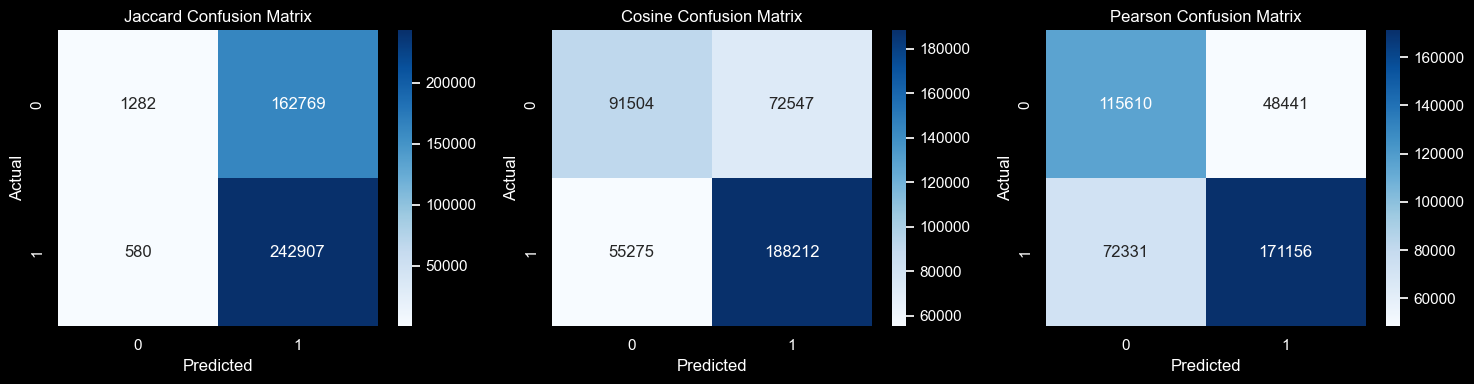

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(jaccard_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Jaccard Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cosine_cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Cosine Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(pearson_cm, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Pearson Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### Visualización comparativa de métricas globales
Comparar visualmente el desempeño entre modelos.

<Figure size 700x400 with 0 Axes>

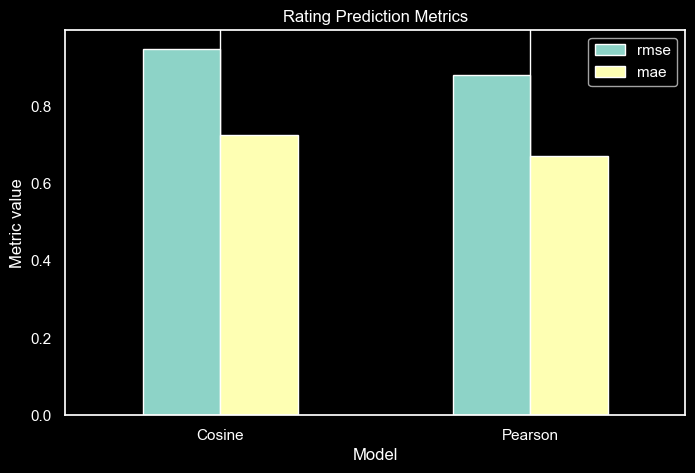

In [109]:
plt.figure(figsize=(7, 4))
rating_metrics_plot = rating_metrics_df.set_index("model")
rating_metrics_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Rating Prediction Metrics")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

<Figure size 1000x400 with 0 Axes>

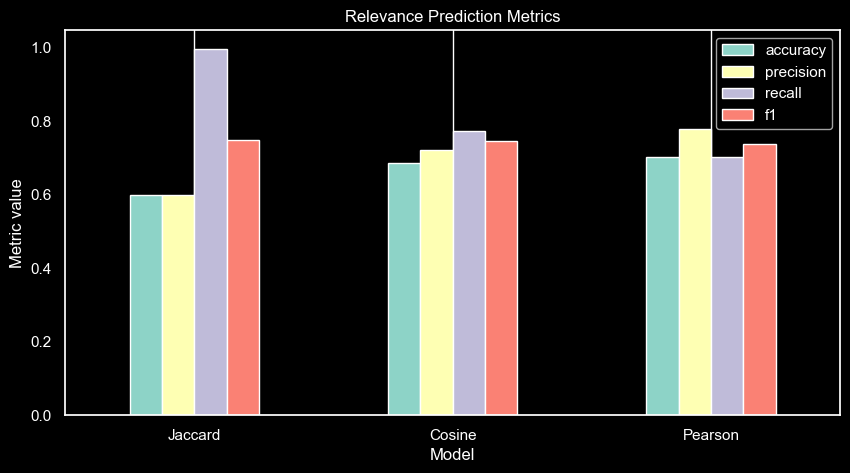

In [110]:
plt.figure(figsize=(10, 4))
relevance_metrics_plot = relevance_metrics_df.set_index("model")
relevance_metrics_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Relevance Prediction Metrics")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

#### Comparación puntual entre rating real y rating predicho
Inspeccionar algunos ejemplos concretos de predicción para Cosine y Pearson.

In [111]:
cosine_examples = cosine_predictions_df[[
    "userId", "movieId", "true_rating", "pred_rating", "true_relevant", "pred_relevant"
]].head(10)

pearson_examples = pearson_predictions_df[[
    "userId", "movieId", "true_rating", "pred_rating", "true_relevant", "pred_relevant"
]].head(10)

print("Cosine examples:")
display(cosine_examples)

print("Pearson examples:")
display(pearson_examples)

Cosine examples:


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant
0,25,1101,3.5,3.611823,1,1
1,25,4886,3.0,4.049760,0,1
2,25,2174,4.0,3.299233,1,0
3,25,2710,3.0,2.762401,0,0
4,25,1080,4.0,3.911752,1,1
5,25,2115,3.5,3.636228,1,1
6,25,4963,3.0,4.062415,0,1
7,25,2797,4.5,3.499521,1,0
8,25,1079,4.0,4.200243,1,1
9,25,1246,4.0,4.200060,1,1


Pearson examples:


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant
0,25,1101,3.5,3.487196,1,0
1,25,4886,3.0,3.979224,0,1
2,25,2174,4.0,3.677643,1,1
3,25,2710,3.0,3.026335,0,0
4,25,1080,4.0,4.088055,1,1
5,25,2115,3.5,3.834924,1,1
6,25,4963,3.0,3.924719,0,1
7,25,2797,4.5,3.465405,1,0
8,25,1079,4.0,4.026664,1,1
9,25,1246,4.0,3.967221,1,1


#### Resumen


In [112]:
summary_df = relevance_metrics_df.merge(
    rating_metrics_df,
    on="model",
    how="left"
)

display(summary_df)

,model,accuracy,precision,recall,f1,rmse,mae
0,Jaccard,0.599181,0.598771,0.997618,0.748370,NaN,NaN
1,Cosine,0.686356,0.721785,0.772986,0.746509,0.949426,0.726455
2,Pearson,0.703655,0.779410,0.702937,0.739201,0.880416,0.670011


La evaluación global de los modelos se realizó desde dos perspectivas. En primer lugar, para los modelos basados en coseno y Pearson, que producen ratings estimados, se calcularon RMSE y MAE. Los resultados muestran que el modelo de Pearson obtuvo mejor desempeño, con RMSE = 0.8804 y MAE = 0.6700, frente a Cosine con RMSE = 0.9494 y MAE = 0.7265. Esto indica que Pearson predice con mayor precisión la calificación explícita observada en el dataset.

En segundo lugar, se evaluó la capacidad de predicción de relevancia binaria mediante accuracy, precision, recall y F1-score. En este escenario, el modelo Jaccard obtuvo un recall extremadamente alto (0.9976), pero a costa de clasificar casi todos los ítems como relevantes, lo que produjo una gran cantidad de falsos positivos y una accuracy relativamente baja.

El modelo Cosine presentó el mejor equilibrio entre precision y recall, alcanzando el mayor F1-score (0.7465), lo que lo convierte en la alternativa más balanceada para predicción binaria de relevancia. Por su parte, Pearson obtuvo la mejor accuracy (0.7037) y la mejor precision (0.7794), lo que sugiere un comportamiento más conservador y confiable al identificar ítems relevantes, aunque sacrificando parte del recall.

En conjunto, los resultados indican que Pearson es superior cuando el objetivo es aproximar el rating real del usuario, mientras que Cosine ofrece el mejor balance general cuando el problema se interpreta como una tarea de clasificación de relevancia. Jaccard, aunque muy fuerte en recall, requiere ajustes adicionales para evitar la sobrepredicción de la clase positiva.

### 3.4. Varíe la estrategia de selección de vecinos por umbral de similitud y por número de vecinos. Revise cuál es el impacto al variar estos parámetros

#### SETUP Experimental
Definir la rejilla experimental y construir un subconjunto fijo de evaluación.

In [113]:
# Experimental setup
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score
)

K_VALUES = [5, 10, 20, 40, 80]
SIM_THRESHOLDS = [0.0, 0.1, 0.2, 0.3]
TEST_EVAL_SAMPLE_SIZE = 30000
RANDOM_STATE = 42
RELEVANCE_THRESHOLD = 3.5

In [114]:
# Build fixed test subsets for faster sensitivity analysis
ratings_binary_test_eval = ratings_binary_test.sample(
    n=min(TEST_EVAL_SAMPLE_SIZE, len(ratings_binary_test)),
    random_state=RANDOM_STATE
).copy()

ratings_explicit_test_eval = ratings_explicit_test[
    ratings_explicit_test.set_index(["userId", "movieId"]).index.isin(
        ratings_binary_test_eval.set_index(["userId", "movieId"]).index
    )
].copy()

test_set_surprise_eval = list(
    ratings_explicit_test_eval[["userId", "movieId", "rating"]]
    .itertuples(index=False, name=None)
)

print("Binary eval sample shape:", ratings_binary_test_eval.shape)
print("Explicit eval sample shape:", ratings_explicit_test_eval.shape)
print("Surprise eval tuples:", len(test_set_surprise_eval))

Binary eval sample shape: (30000, 4)
Explicit eval sample shape: (30000, 4)
Surprise eval tuples: 30000


#### Funciones de evaluación
Dejar funciones compactas para correr el experimento sin repetir código.

In [115]:
# Reuse Jaccard prediction function with configurable k and min_similarity
def evaluate_jaccard_config(
    ratings_binary_test_eval,
    user_items_positive_train,
    user_binary_feedback_train,
    item_users_train,
    user_relevance_mean_train,
    global_relevance_mean,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    y_true = []
    y_pred = []
    neighbors_used_list = []

    for row in ratings_binary_test_eval.itertuples(index=False):
        pred_score, pred_relevant, neighbors_used = predict_jaccard_relevance(
            user_id=row.userId,
            movie_id=row.movieId,
            user_items_positive_train=user_items_positive_train,
            user_binary_feedback_train=user_binary_feedback_train,
            item_users_train=item_users_train,
            user_relevance_mean_train=user_relevance_mean_train,
            global_relevance_mean=global_relevance_mean,
            top_k=top_k,
            min_similarity=min_similarity,
            threshold=threshold
        )

        y_true.append(row.relevant)
        y_pred.append(pred_relevant)
        neighbors_used_list.append(neighbors_used)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "avg_neighbors_used": float(np.mean(neighbors_used_list)),
        "pct_zero_neighbors": float(np.mean(np.array(neighbors_used_list) == 0))
    }

In [117]:
# Evaluate Surprise model with a given test set
def evaluate_surprise_predictions(predictions, relevance_threshold=3.5):
    y_true_rating = np.array([pred.r_ui for pred in predictions], dtype=float)
    y_pred_rating = np.array([pred.est for pred in predictions], dtype=float)

    y_true_rel = (y_true_rating >= relevance_threshold).astype(int)
    y_pred_rel = (y_pred_rating >= relevance_threshold).astype(int)

    actual_k_values = [
        pred.details.get("actual_k", np.nan) for pred in predictions
    ]
    actual_k_values = np.array(actual_k_values, dtype=float)

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true_rating, y_pred_rating))),
        "mae": float(mean_absolute_error(y_true_rating, y_pred_rating)),
        "f1": float(f1_score(y_true_rel, y_pred_rel, zero_division=0)),
        "avg_actual_k": float(np.nanmean(actual_k_values)),
        "pct_zero_neighbors": float(np.nanmean(actual_k_values == 0))
    }

#### Correr experimentos de sensitividad

In [118]:
# 3.1 Jaccard over k
jaccard_k_results = []

for k in K_VALUES:
    metrics = evaluate_jaccard_config(
        ratings_binary_test_eval=ratings_binary_test_eval,
        user_items_positive_train=user_items_positive_train,
        user_binary_feedback_train=user_binary_feedback_train,
        item_users_train=item_users_train,
        user_relevance_mean_train=user_relevance_mean_train,
        global_relevance_mean=global_relevance_mean,
        top_k=k,
        min_similarity=0.0,
        threshold=0.5
    )

    jaccard_k_results.append({
        "model": "Jaccard",
        "k": k,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "avg_neighbors_used": metrics["avg_neighbors_used"],
        "pct_zero_neighbors": metrics["pct_zero_neighbors"]
    })

jaccard_k_results_df = pd.DataFrame(jaccard_k_results)
display(jaccard_k_results_df)

,model,k,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard,5,0.598989,0.997713,0.748567,4.836300,0.013767
1,Jaccard,10,0.598989,0.997713,0.748567,9.482000,0.013767
2,Jaccard,20,0.598989,0.997713,0.748567,18.345367,0.013767
3,Jaccard,40,0.598989,0.997713,0.748567,34.797100,0.013767
4,Jaccard,80,0.598989,0.997713,0.748567,64.222000,0.013767


In [119]:
# 3.2 Jaccard over similarity threshold
jaccard_threshold_results = []

for sim_threshold in SIM_THRESHOLDS:
    metrics = evaluate_jaccard_config(
        ratings_binary_test_eval=ratings_binary_test_eval,
        user_items_positive_train=user_items_positive_train,
        user_binary_feedback_train=user_binary_feedback_train,
        item_users_train=item_users_train,
        user_relevance_mean_train=user_relevance_mean_train,
        global_relevance_mean=global_relevance_mean,
        top_k=40,
        min_similarity=sim_threshold,
        threshold=0.5
    )

    jaccard_threshold_results.append({
        "model": "Jaccard",
        "min_similarity": sim_threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "avg_neighbors_used": metrics["avg_neighbors_used"],
        "pct_zero_neighbors": metrics["pct_zero_neighbors"]
    })

jaccard_threshold_results_df = pd.DataFrame(jaccard_threshold_results)
display(jaccard_threshold_results_df)

,model,min_similarity,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard,0.0,0.598989,0.997713,0.748567,34.797100,0.013767
1,Jaccard,0.1,0.608592,0.978919,0.750561,24.547667,0.108900
2,Jaccard,0.2,0.649245,0.901288,0.754781,5.879367,0.527133
3,Jaccard,0.3,0.669334,0.834923,0.743015,0.494667,0.924367


In [120]:
# 3.3 Cosine and Pearson over k
reader = Reader(rating_scale=(0.5, 5.0))
train_dataset = Dataset.load_from_df(
    ratings_explicit_train[["userId", "movieId", "rating"]],
    reader
)
trainset = train_dataset.build_full_trainset()

cosine_k_results = []
pearson_k_results = []

for k in K_VALUES:
    # Cosine
    cosine_algo = KNNBasic(
        k=k,
        min_k=1,
        sim_options={"name": "cosine", "user_based": True},
        verbose=False
    )
    cosine_algo.fit(trainset)
    cosine_preds = cosine_algo.test(test_set_surprise_eval)
    cosine_metrics = evaluate_surprise_predictions(
        cosine_preds,
        relevance_threshold=RELEVANCE_THRESHOLD
    )

    cosine_k_results.append({
        "model": "Cosine",
        "k": k,
        "rmse": cosine_metrics["rmse"],
        "mae": cosine_metrics["mae"],
        "f1": cosine_metrics["f1"],
        "avg_actual_k": cosine_metrics["avg_actual_k"],
        "pct_zero_neighbors": cosine_metrics["pct_zero_neighbors"]
    })

    # Pearson
    pearson_algo = KNNWithMeans(
        k=k,
        min_k=1,
        sim_options={"name": "pearson", "user_based": True},
        verbose=False
    )
    pearson_algo.fit(trainset)
    pearson_preds = pearson_algo.test(test_set_surprise_eval)
    pearson_metrics = evaluate_surprise_predictions(
        pearson_preds,
        relevance_threshold=RELEVANCE_THRESHOLD
    )

    pearson_k_results.append({
        "model": "Pearson",
        "k": k,
        "rmse": pearson_metrics["rmse"],
        "mae": pearson_metrics["mae"],
        "f1": pearson_metrics["f1"],
        "avg_actual_k": pearson_metrics["avg_actual_k"],
        "pct_zero_neighbors": pearson_metrics["pct_zero_neighbors"]
    })

cosine_k_results_df = pd.DataFrame(cosine_k_results)
pearson_k_results_df = pd.DataFrame(pearson_k_results)

display(cosine_k_results_df)
display(pearson_k_results_df)

,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Cosine,5,1.038166,0.799186,0.709362,4.949392,0.0
1,Cosine,10,0.989359,0.758970,0.728897,9.792123,0.0
2,Cosine,20,0.962434,0.737545,0.741916,19.232274,0.0
3,Cosine,40,0.947110,0.724741,0.748715,37.318906,0.0
4,Cosine,80,0.938810,0.717817,0.749560,71.073661,0.0


,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Pearson,5,0.960197,0.737617,0.714374,4.931620,0.0016
1,Pearson,10,0.918074,0.703826,0.726659,9.741196,0.0016
2,Pearson,20,0.894268,0.683497,0.734581,19.073353,0.0016
3,Pearson,40,0.882389,0.673309,0.739255,36.818985,0.0016
4,Pearson,80,0.877207,0.668050,0.742189,69.464550,0.0016


#### Resultados

In [121]:
# Consolidated tables
surprise_k_results_df = pd.concat(
    [cosine_k_results_df, pearson_k_results_df],
    ignore_index=True
)

display(jaccard_k_results_df)
display(jaccard_threshold_results_df)
display(surprise_k_results_df)

,model,k,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard,5,0.598989,0.997713,0.748567,4.836300,0.013767
1,Jaccard,10,0.598989,0.997713,0.748567,9.482000,0.013767
2,Jaccard,20,0.598989,0.997713,0.748567,18.345367,0.013767
3,Jaccard,40,0.598989,0.997713,0.748567,34.797100,0.013767
4,Jaccard,80,0.598989,0.997713,0.748567,64.222000,0.013767


,model,min_similarity,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard,0.0,0.598989,0.997713,0.748567,34.797100,0.013767
1,Jaccard,0.1,0.608592,0.978919,0.750561,24.547667,0.108900
2,Jaccard,0.2,0.649245,0.901288,0.754781,5.879367,0.527133
3,Jaccard,0.3,0.669334,0.834923,0.743015,0.494667,0.924367


,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Cosine,5,1.038166,0.799186,0.709362,4.949392,0.0000
1,Cosine,10,0.989359,0.758970,0.728897,9.792123,0.0000
2,Cosine,20,0.962434,0.737545,0.741916,19.232274,0.0000
3,Cosine,40,0.947110,0.724741,0.748715,37.318906,0.0000
4,Cosine,80,0.938810,0.717817,0.749560,71.073661,0.0000
5,Pearson,5,0.960197,0.737617,0.714374,4.931620,0.0016
6,Pearson,10,0.918074,0.703826,0.726659,9.741196,0.0016
7,Pearson,20,0.894268,0.683497,0.734581,19.073353,0.0016
8,Pearson,40,0.882389,0.673309,0.739255,36.818985,0.0016
9,Pearson,80,0.877207,0.668050,0.742189,69.464550,0.0016


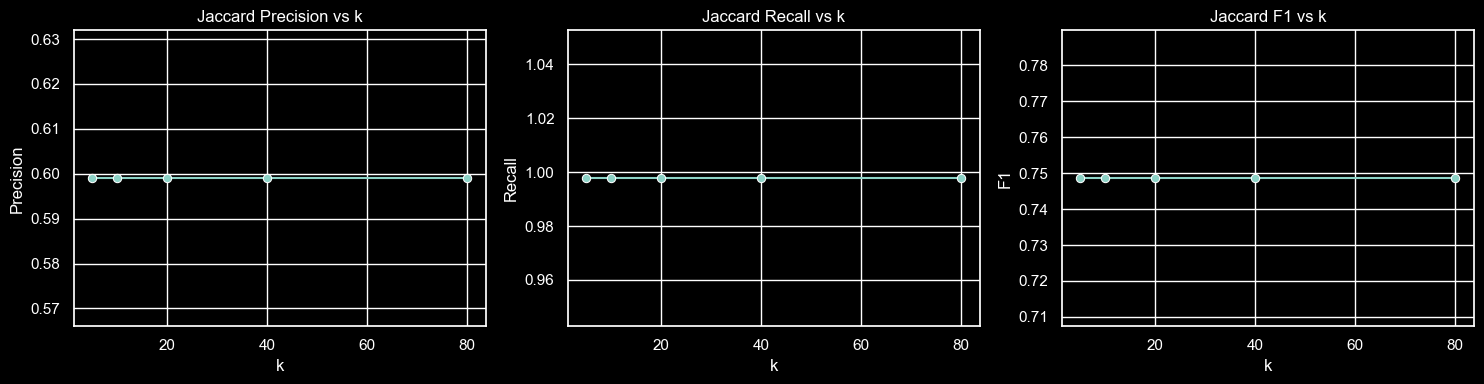

In [122]:
# Plot 1: Jaccard metrics vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_k_results_df, x="k", y="precision", marker="o", ax=axes[0])
axes[0].set_title("Jaccard Precision vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Precision")

sns.lineplot(data=jaccard_k_results_df, x="k", y="recall", marker="o", ax=axes[1])
axes[1].set_title("Jaccard Recall vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Recall")

sns.lineplot(data=jaccard_k_results_df, x="k", y="f1", marker="o", ax=axes[2])
axes[2].set_title("Jaccard F1 vs k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

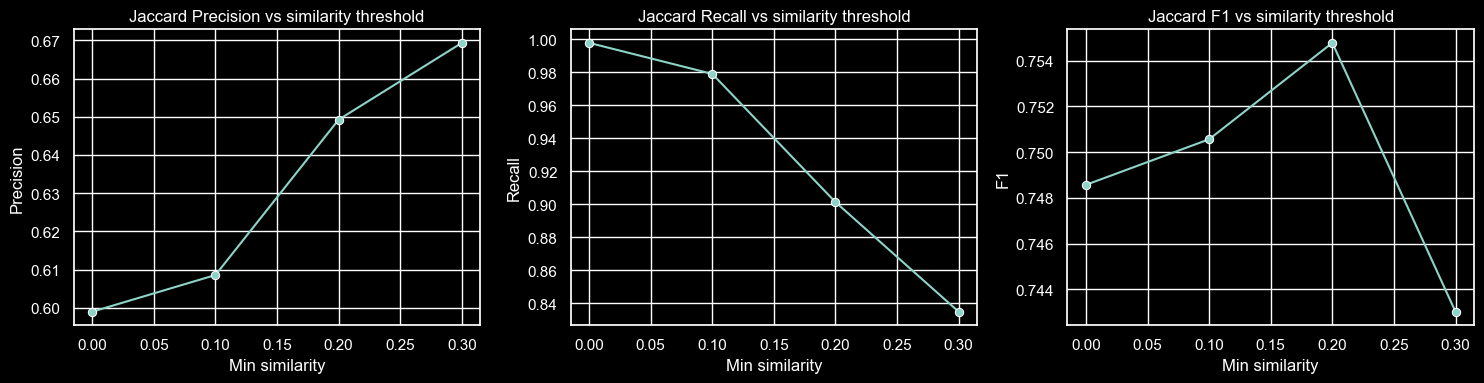

In [123]:
# Plot 2: Jaccard metrics vs similarity threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_threshold_results_df, x="min_similarity", y="precision", marker="o", ax=axes[0])
axes[0].set_title("Jaccard Precision vs similarity threshold")
axes[0].set_xlabel("Min similarity")
axes[0].set_ylabel("Precision")

sns.lineplot(data=jaccard_threshold_results_df, x="min_similarity", y="recall", marker="o", ax=axes[1])
axes[1].set_title("Jaccard Recall vs similarity threshold")
axes[1].set_xlabel("Min similarity")
axes[1].set_ylabel("Recall")

sns.lineplot(data=jaccard_threshold_results_df, x="min_similarity", y="f1", marker="o", ax=axes[2])
axes[2].set_title("Jaccard F1 vs similarity threshold")
axes[2].set_xlabel("Min similarity")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

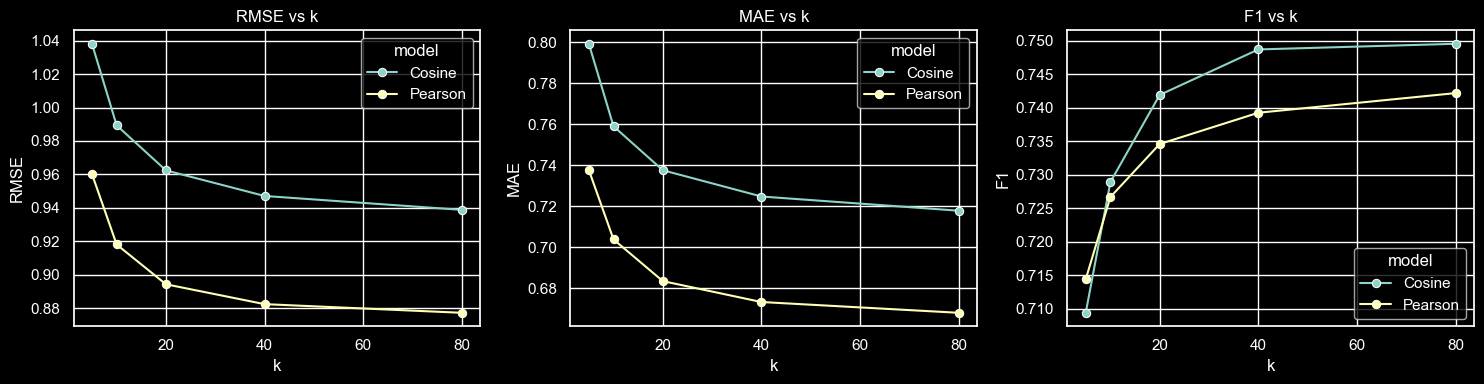

In [124]:
# Plot 3: Cosine and Pearson metrics vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=surprise_k_results_df, x="k", y="rmse", hue="model", marker="o", ax=axes[0])
axes[0].set_title("RMSE vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("RMSE")

sns.lineplot(data=surprise_k_results_df, x="k", y="mae", hue="model", marker="o", ax=axes[1])
axes[1].set_title("MAE vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("MAE")

sns.lineplot(data=surprise_k_results_df, x="k", y="f1", hue="model", marker="o", ax=axes[2])
axes[2].set_title("F1 vs k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

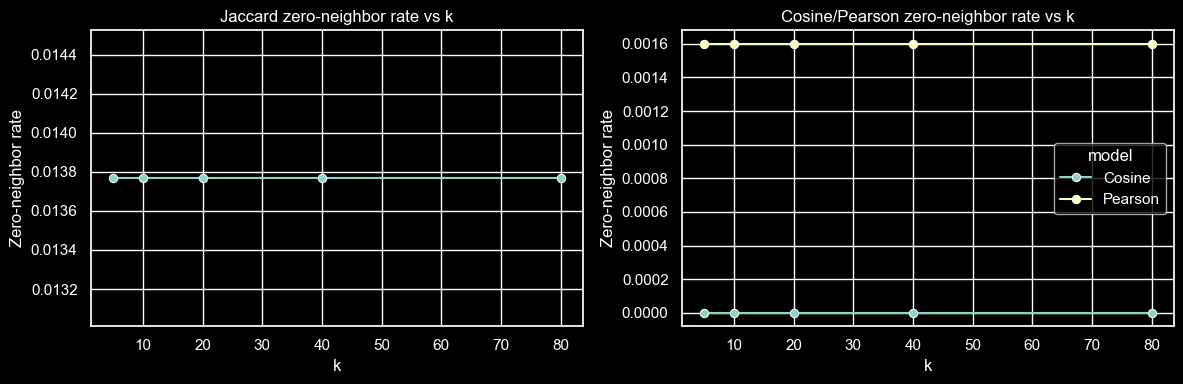

In [125]:
# Optional: neighbor usage diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=jaccard_k_results_df, x="k", y="pct_zero_neighbors", marker="o", ax=axes[0])
axes[0].set_title("Jaccard zero-neighbor rate vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Zero-neighbor rate")

sns.lineplot(data=surprise_k_results_df, x="k", y="pct_zero_neighbors", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Cosine/Pearson zero-neighbor rate vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Zero-neighbor rate")

plt.tight_layout()
plt.show()

Para analizar el impacto de la estrategia de selección de vecinos se evaluó el efecto de variar el número máximo de vecinos (k) y, en el caso del modelo Jaccard, el umbral mínimo de similitud requerido para aceptar un vecino.

En el modelo Jaccard, variar k entre 5 y 80 no produjo cambios en precision, recall ni F1-score, aunque sí incrementó el número promedio de vecinos utilizados. Esto indica que el comportamiento del modelo no estaba determinado por la cantidad de vecinos, sino por la permisividad del criterio de similitud. En contraste, al aumentar el umbral mínimo de similitud se observó una mejora clara en precision y una reducción progresiva del recall. El mejor equilibrio se obtuvo alrededor de min_similarity = 0.2, donde el modelo alcanzó su mayor F1-score. Umbrales más altos redujeron excesivamente la cantidad de vecinos disponibles, elevando la tasa de casos sin vecinos y deteriorando el rendimiento global.

En los modelos basados en coseno y Pearson, el número de vecinos sí tuvo un impacto claro. A medida que k aumentó, RMSE y MAE disminuyeron de forma consistente, mientras que F1-score mejoró gradualmente. Esto sugiere que ambos modelos se benefician de incorporar más vecinos, probablemente porque el perfil agregado se vuelve más estable y menos sensible al ruido individual. No obstante, la mejora marginal entre k = 40 y k = 80 fue reducida, lo que indica la existencia de rendimientos decrecientes.

En conjunto, los resultados muestran que la sensibilidad a los parámetros depende del modelo. Jaccard es especialmente sensible al umbral de similitud, mientras que Cosine y Pearson responden principalmente al número de vecinos. Además, Pearson mantuvo el mejor desempeño en predicción de rating para todos los valores de k, mientras que Cosine mostró un comportamiento ligeramente mejor en términos de F1 para relevancia.

### 3.5 Revise la estrategia de ponderación por significancia de McLaughlin’s [1] (McLaughlin’s significance weighting) y revise cuál es el impacto al variar los parámetros de esta estrategia.

#### Experimental setup and auxiliary structures
Definir la configuración base, crear una submuestra fija de evaluación y preparar estructuras auxiliares para calcular la significancia.

In [131]:
# Experimental setup for significance weighting
BETA_VALUES = [5, 10, 20, 40]

JACCARD_BASE_K = 40
JACCARD_BASE_MIN_SIM = 0.2

COSINE_BASE_K = 40
PEARSON_BASE_K = 40

SIG_TEST_EVAL_SAMPLE_SIZE = 10000
SIG_RANDOM_STATE = 42
RATING_THRESHOLD = 3.5
RELEVANCE_THRESHOLD = 0.5

In [132]:
# Build a smaller fixed evaluation subset for significance-weighting experiments
ratings_binary_test_sig = ratings_binary_test.sample(
    n=min(SIG_TEST_EVAL_SAMPLE_SIZE, len(ratings_binary_test)),
    random_state=SIG_RANDOM_STATE
).copy()

ratings_explicit_test_sig = ratings_explicit_test[
    ratings_explicit_test.set_index(["userId", "movieId"]).index.isin(
        ratings_binary_test_sig.set_index(["userId", "movieId"]).index
    )
].copy()

print("Binary significance-eval sample:", ratings_binary_test_sig.shape)
print("Explicit significance-eval sample:", ratings_explicit_test_sig.shape)

Binary significance-eval sample: (10000, 4)
Explicit significance-eval sample: (10000, 4)


In [133]:
# Auxiliary structures from train
user_items_all_train = (
    ratings_explicit_train
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

user_mean_rating_train = (
    ratings_explicit_train
    .groupby("userId")["rating"]
    .mean()
    .to_dict()
)

item_ratings_train = (
    ratings_explicit_train
    .groupby("movieId")
    .apply(lambda x: list(zip(x["userId"], x["rating"])))
    .to_dict()
)

global_mean_rating_train = ratings_explicit_train["rating"].mean()

print("Users in user_items_all_train:", len(user_items_all_train))
print("Items in item_ratings_train:", len(item_ratings_train))
print("Global mean rating:", round(global_mean_rating_train, 4))

Users in user_items_all_train: 13850
Items in item_ratings_train: 15311
Global mean rating: 3.5418


#### Funciones de predicción con ponderación de significancia
Definir la lógica para ajustar la similitud por significancia y evaluar cada configuración.

In [134]:
def significance_weight(common_count, beta):
    """
    McLaughlin-style significance weighting:
    w = min(1, common_count / beta)
    """
    return min(1.0, common_count / beta)

In [135]:
def predict_jaccard_with_significance(
    user_id,
    movie_id,
    user_items_positive_train,
    user_binary_feedback_train,
    item_users_train,
    user_relevance_mean_train,
    global_relevance_mean,
    beta,
    top_k=40,
    min_similarity=0.2,
    threshold=0.5
):
    """
    Predict binary relevance with Jaccard + significance weighting.
    """
    target_user_items = user_items_positive_train.get(user_id, set())
    candidate_users = item_users_train.get(movie_id, set()) - {user_id}

    scored_neighbors = []

    for neighbor_id in candidate_users:
        neighbor_items = user_items_positive_train.get(neighbor_id, set())

        base_sim = jaccard_similarity(target_user_items, neighbor_items)
        common_count = len(target_user_items & neighbor_items)
        adjusted_sim = base_sim * significance_weight(common_count, beta)

        if adjusted_sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(neighbor_id, {}).get(movie_id, 0)
            scored_neighbors.append((neighbor_id, adjusted_sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        pred_relevant = int(fallback_score >= threshold)
        return fallback_score, pred_relevant, 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        pred_relevant = int(fallback_score >= threshold)
        return fallback_score, pred_relevant, 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

In [136]:
def predict_surprise_with_significance(
    user_id,
    movie_id,
    algo,
    model_type,
    user_items_all_train,
    user_mean_rating_train,
    item_ratings_train,
    global_mean_rating_train,
    beta,
    top_k=40,
    min_similarity=0.0,
    rating_threshold=3.5
):
    """
    Predict rating/relevance manually using Surprise similarity matrix
    + significance weighting.
    model_type: 'cosine' or 'pearson'
    """
    # Fallbacks for unknown users/items
    if movie_id not in item_ratings_train:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    try:
        user_inner = algo.trainset.to_inner_uid(user_id)
    except ValueError:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    candidate_users = item_ratings_train.get(movie_id, [])
    scored_neighbors = []

    for neighbor_id, neighbor_rating in candidate_users:
        if neighbor_id == user_id:
            continue

        try:
            neighbor_inner = algo.trainset.to_inner_uid(neighbor_id)
        except ValueError:
            continue

        base_sim = algo.sim[user_inner, neighbor_inner]

        common_count = len(
            user_items_all_train.get(user_id, set()) &
            user_items_all_train.get(neighbor_id, set())
        )

        adjusted_sim = base_sim * significance_weight(common_count, beta)

        if adjusted_sim > min_similarity:
            scored_neighbors.append((neighbor_id, adjusted_sim, neighbor_rating))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    if model_type == "cosine":
        numerator = sum(sim * rating for _, sim, rating in scored_neighbors)
        denominator = sum(sim for _, sim, _ in scored_neighbors)

        if denominator == 0:
            fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
            return fallback_rating, int(fallback_rating >= rating_threshold), 0

        pred_rating = numerator / denominator

    elif model_type == "pearson":
        user_mean = user_mean_rating_train.get(user_id, global_mean_rating_train)

        numerator = 0.0
        denominator = 0.0

        for neighbor_id, sim, neighbor_rating in scored_neighbors:
            neighbor_mean = user_mean_rating_train.get(neighbor_id, global_mean_rating_train)
            numerator += sim * (neighbor_rating - neighbor_mean)
            denominator += abs(sim)

        if denominator == 0:
            fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
            return fallback_rating, int(fallback_rating >= rating_threshold), 0

        pred_rating = user_mean + (numerator / denominator)

    else:
        raise ValueError("model_type must be 'cosine' or 'pearson'")

    pred_relevant = int(pred_rating >= rating_threshold)
    return pred_rating, pred_relevant, len(scored_neighbors)

In [137]:
def evaluate_jaccard_significance_config(beta):
    y_true = []
    y_pred = []
    neighbors_used_list = []

    for row in ratings_binary_test_sig.itertuples(index=False):
        pred_score, pred_relevant, neighbors_used = predict_jaccard_with_significance(
            user_id=row.userId,
            movie_id=row.movieId,
            user_items_positive_train=user_items_positive_train,
            user_binary_feedback_train=user_binary_feedback_train,
            item_users_train=item_users_train,
            user_relevance_mean_train=user_relevance_mean_train,
            global_relevance_mean=global_relevance_mean,
            beta=beta,
            top_k=JACCARD_BASE_K,
            min_similarity=JACCARD_BASE_MIN_SIM,
            threshold=RELEVANCE_THRESHOLD
        )

        y_true.append(row.relevant)
        y_pred.append(pred_relevant)
        neighbors_used_list.append(neighbors_used)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "avg_neighbors_used": float(np.mean(neighbors_used_list)),
        "pct_zero_neighbors": float(np.mean(np.array(neighbors_used_list) == 0))
    }

In [140]:
def evaluate_surprise_significance_config(algo, model_type, beta, top_k):
    y_true_rating = []
    y_pred_rating = []
    y_true_rel = []
    y_pred_rel = []
    neighbors_used_list = []

    for row in ratings_explicit_test_sig.itertuples(index=False):
        pred_rating, pred_relevant, neighbors_used = predict_surprise_with_significance(
            user_id=row.userId,
            movie_id=row.movieId,
            algo=algo,
            model_type=model_type,
            user_items_all_train=user_items_all_train,
            user_mean_rating_train=user_mean_rating_train,
            item_ratings_train=item_ratings_train,
            global_mean_rating_train=global_mean_rating_train,
            beta=beta,
            top_k=top_k,
            min_similarity=0.0,
            rating_threshold=RATING_THRESHOLD
        )

        y_true_rating.append(row.rating)
        y_pred_rating.append(pred_rating)
        y_true_rel.append(int(row.rating >= RATING_THRESHOLD))
        y_pred_rel.append(pred_relevant)
        neighbors_used_list.append(neighbors_used)

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true_rating, y_pred_rating))),
        "mae": float(mean_absolute_error(y_true_rating, y_pred_rating)),
        "f1": float(f1_score(y_true_rel, y_pred_rel, zero_division=0)),
        "avg_neighbors_used": float(np.mean(neighbors_used_list)),
        "pct_zero_neighbors": float(np.mean(np.array(neighbors_used_list) == 0))
    }

#### Realizar experimentos de ponderación de significancia
Realizar experimentos de ponderación de significancia

In [139]:
# Jaccard over beta
jaccard_significance_results = []

for beta in BETA_VALUES:
    metrics = evaluate_jaccard_significance_config(beta=beta)

    jaccard_significance_results.append({
        "model": "Jaccard",
        "beta": beta,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "avg_neighbors_used": metrics["avg_neighbors_used"],
        "pct_zero_neighbors": metrics["pct_zero_neighbors"]
    })

jaccard_significance_results_df = pd.DataFrame(jaccard_significance_results)
display(jaccard_significance_results_df)

,model,beta,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard,5,0.643703,0.898448,0.750035,5.8411,0.5218
1,Jaccard,10,0.645585,0.895412,0.750247,5.6598,0.5305
2,Jaccard,20,0.649623,0.887314,0.750089,5.1035,0.5579
3,Jaccard,40,0.655769,0.876350,0.750181,4.4423,0.6118


In [141]:
# Cosine and Pearson over beta
cosine_significance_results = []
pearson_significance_results = []

for beta in BETA_VALUES:
    cosine_metrics = evaluate_surprise_significance_config(
        algo=cosine_model,
        model_type="cosine",
        beta=beta,
        top_k=COSINE_BASE_K
    )

    cosine_significance_results.append({
        "model": "Cosine",
        "beta": beta,
        "rmse": cosine_metrics["rmse"],
        "mae": cosine_metrics["mae"],
        "f1": cosine_metrics["f1"],
        "avg_neighbors_used": cosine_metrics["avg_neighbors_used"],
        "pct_zero_neighbors": cosine_metrics["pct_zero_neighbors"]
    })

    pearson_metrics = evaluate_surprise_significance_config(
        algo=pearson_model,
        model_type="pearson",
        beta=beta,
        top_k=PEARSON_BASE_K
    )

    pearson_significance_results.append({
        "model": "Pearson",
        "beta": beta,
        "rmse": pearson_metrics["rmse"],
        "mae": pearson_metrics["mae"],
        "f1": pearson_metrics["f1"],
        "avg_neighbors_used": pearson_metrics["avg_neighbors_used"],
        "pct_zero_neighbors": pearson_metrics["pct_zero_neighbors"]
    })

cosine_significance_results_df = pd.DataFrame(cosine_significance_results)
pearson_significance_results_df = pd.DataFrame(pearson_significance_results)

display(cosine_significance_results_df)
display(pearson_significance_results_df)

,model,beta,rmse,mae,f1,avg_neighbors_used,pct_zero_neighbors
0,Cosine,5,0.953616,0.726952,0.756632,37.1282,0.0071
1,Cosine,10,0.950009,0.724219,0.757643,37.1282,0.0071
2,Cosine,20,0.948888,0.723432,0.754653,37.1282,0.0071
3,Cosine,40,0.950300,0.726358,0.746349,37.1282,0.0071


,model,beta,rmse,mae,f1,avg_neighbors_used,pct_zero_neighbors
0,Pearson,5,0.877121,0.670513,0.742489,36.6392,0.009
1,Pearson,10,0.872716,0.666598,0.745139,36.6392,0.009
2,Pearson,20,0.869406,0.662051,0.752656,36.6392,0.009
3,Pearson,40,0.870056,0.661848,0.757364,36.6392,0.009


#### Resultados
Consolidar resultados y compararlos visualmente contra el baseline sin significance weighting.

In [142]:
# Consolidate results
significance_results_df = pd.concat(
    [
        jaccard_significance_results_df,
        cosine_significance_results_df,
        pearson_significance_results_df
    ],
    ignore_index=True
)

display(significance_results_df)

,model,beta,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors,rmse,mae
0,Jaccard,5,0.643703,0.898448,0.750035,5.8411,0.5218,NaN,NaN
1,Jaccard,10,0.645585,0.895412,0.750247,5.6598,0.5305,NaN,NaN
2,Jaccard,20,0.649623,0.887314,0.750089,5.1035,0.5579,NaN,NaN
3,Jaccard,40,0.655769,0.876350,0.750181,4.4423,0.6118,NaN,NaN
4,Cosine,5,NaN,NaN,0.756632,37.1282,0.0071,0.953616,0.726952
5,Cosine,10,NaN,NaN,0.757643,37.1282,0.0071,0.950009,0.724219
6,Cosine,20,NaN,NaN,0.754653,37.1282,0.0071,0.948888,0.723432
7,Cosine,40,NaN,NaN,0.746349,37.1282,0.0071,0.950300,0.726358
8,Pearson,5,NaN,NaN,0.742489,36.6392,0.0090,0.877121,0.670513
9,Pearson,10,NaN,NaN,0.745139,36.6392,0.0090,0.872716,0.666598


In [143]:
# Optional baseline comparison (from point 3d)
baseline_comparison = pd.DataFrame([
    {
        "model": "Jaccard",
        "beta": 0,
        "precision": jaccard_threshold_results_df.loc[
            jaccard_threshold_results_df["min_similarity"] == JACCARD_BASE_MIN_SIM,
            "precision"
        ].iloc[0],
        "recall": jaccard_threshold_results_df.loc[
            jaccard_threshold_results_df["min_similarity"] == JACCARD_BASE_MIN_SIM,
            "recall"
        ].iloc[0],
        "f1": jaccard_threshold_results_df.loc[
            jaccard_threshold_results_df["min_similarity"] == JACCARD_BASE_MIN_SIM,
            "f1"
        ].iloc[0],
    },
    {
        "model": "Cosine",
        "beta": 0,
        "rmse": cosine_k_results_df.loc[
            cosine_k_results_df["k"] == COSINE_BASE_K,
            "rmse"
        ].iloc[0],
        "mae": cosine_k_results_df.loc[
            cosine_k_results_df["k"] == COSINE_BASE_K,
            "mae"
        ].iloc[0],
        "f1": cosine_k_results_df.loc[
            cosine_k_results_df["k"] == COSINE_BASE_K,
            "f1"
        ].iloc[0],
    },
    {
        "model": "Pearson",
        "beta": 0,
        "rmse": pearson_k_results_df.loc[
            pearson_k_results_df["k"] == PEARSON_BASE_K,
            "rmse"
        ].iloc[0],
        "mae": pearson_k_results_df.loc[
            pearson_k_results_df["k"] == PEARSON_BASE_K,
            "mae"
        ].iloc[0],
        "f1": pearson_k_results_df.loc[
            pearson_k_results_df["k"] == PEARSON_BASE_K,
            "f1"
        ].iloc[0],
    },
])

display(baseline_comparison)

,model,beta,precision,recall,f1,rmse,mae
0,Jaccard,0,0.649245,0.901288,0.754781,NaN,NaN
1,Cosine,0,NaN,NaN,0.748715,0.947110,0.724741
2,Pearson,0,NaN,NaN,0.739255,0.882389,0.673309


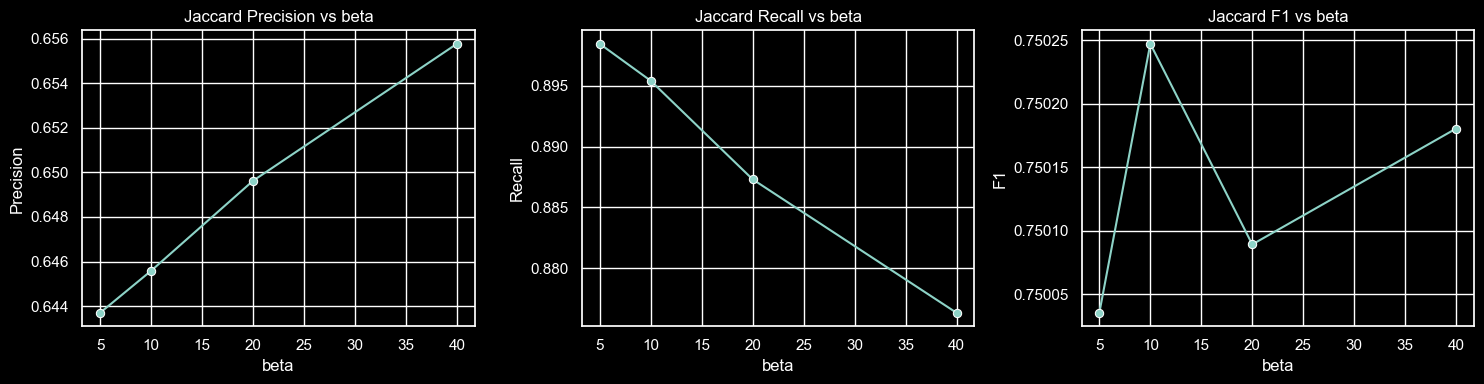

In [144]:
# Plot 1: Jaccard vs beta
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_significance_results_df, x="beta", y="precision", marker="o", ax=axes[0])
axes[0].set_title("Jaccard Precision vs beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("Precision")

sns.lineplot(data=jaccard_significance_results_df, x="beta", y="recall", marker="o", ax=axes[1])
axes[1].set_title("Jaccard Recall vs beta")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Recall")

sns.lineplot(data=jaccard_significance_results_df, x="beta", y="f1", marker="o", ax=axes[2])
axes[2].set_title("Jaccard F1 vs beta")
axes[2].set_xlabel("beta")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

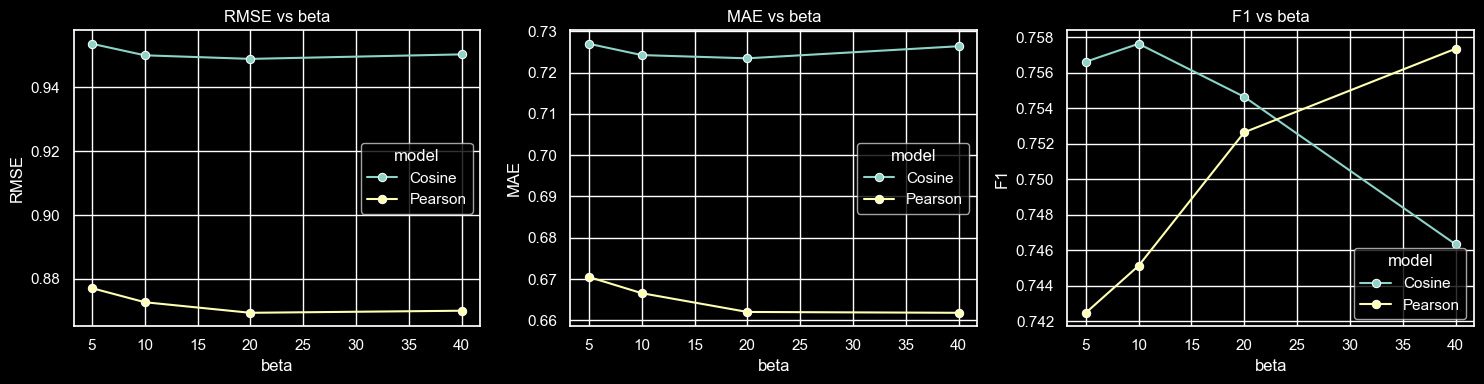

In [145]:
# Plot 2: Cosine and Pearson vs beta
surprise_significance_results_df = pd.concat(
    [cosine_significance_results_df, pearson_significance_results_df],
    ignore_index=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=surprise_significance_results_df, x="beta", y="rmse", hue="model", marker="o", ax=axes[0])
axes[0].set_title("RMSE vs beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("RMSE")

sns.lineplot(data=surprise_significance_results_df, x="beta", y="mae", hue="model", marker="o", ax=axes[1])
axes[1].set_title("MAE vs beta")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("MAE")

sns.lineplot(data=surprise_significance_results_df, x="beta", y="f1", hue="model", marker="o", ax=axes[2])
axes[2].set_title("F1 vs beta")
axes[2].set_xlabel("beta")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

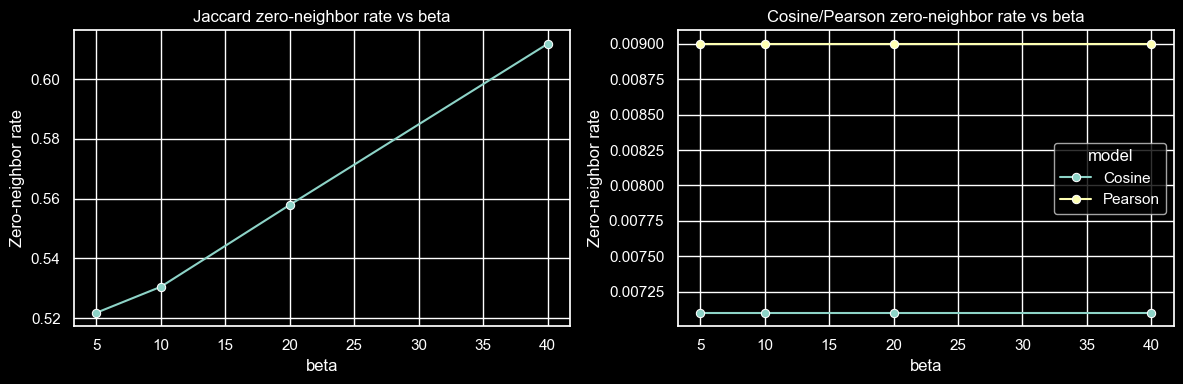

In [146]:
# Plot 3: neighbor usage diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=jaccard_significance_results_df, x="beta", y="pct_zero_neighbors", marker="o", ax=axes[0])
axes[0].set_title("Jaccard zero-neighbor rate vs beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("Zero-neighbor rate")

sns.lineplot(data=surprise_significance_results_df, x="beta", y="pct_zero_neighbors", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Cosine/Pearson zero-neighbor rate vs beta")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Zero-neighbor rate")

plt.tight_layout()
plt.show()

La estrategia de McLaughlin’s significance weighting mostró impactos distintos según el modelo considerado. En el caso de Jaccard, el aumento del parámetro beta produjo un incremento gradual en precision y una reducción en recall, mientras que el F1-score permaneció prácticamente estable. Esto indica que la estrategia permitió regular el balance entre recuperación y selectividad, pero no generó una mejora sustancial en el desempeño global.

En el modelo basado en coseno, la significance weighting produjo mejoras leves tanto en RMSE y MAE como en F1-score para valores moderados de beta, aunque una penalización demasiado fuerte deterioró parcialmente la clasificación. Esto sugiere que el coseno ya era relativamente robusto y que la estrategia aporta solo una ganancia incremental.

El mayor impacto se observó en el modelo basado en correlación de Pearson. A medida que aumentó beta, RMSE y MAE disminuyeron de forma consistente y el F1-score mejoró respecto al baseline sin significance weighting. Esto sugiere que Pearson se beneficia claramente de penalizar similitudes calculadas sobre poca evidencia compartida, lo que hace al vecindario más confiable y robusto.

En conjunto, los resultados muestran que la estrategia de significance weighting es especialmente útil en modelos cuya similitud puede inflarse con pocos co-ratings, siendo Pearson el caso donde se observó la mejora más clara.

## 4. Construcción de modelos colaborativos ítem - ítem

### 4.1. Construya un modelo colaborativo
### 4.2. Realice las predicciones de relevancia para los usuarios e ítems que encuentra en la segunda parte de los datos
### 4.3. Compare su predicción de rating con el efectivamente encontrado en el dataset. Establezca una forma de evaluar globalmente sus distancias en las predicciones que refleje la calidad de las mism

#### Cargar data y construir modelos item-item

In [147]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

from surprise import Dataset, Reader
from surprise import KNNBasic, KNNWithMeans

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [171]:
processed_dir = Path("./processed")
models_dir = Path("./models")
WORKING_SAMPLE_KEY = "30pct"
RATING_THRESHOLD = 3.5
ITEM_K = 40
ITEM_MIN_K = 1

In [172]:
# Load datasets
ratings_explicit_train = pd.read_parquet(
    processed_dir / f"ratings_explicit_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_explicit_test = pd.read_parquet(
    processed_dir / f"ratings_explicit_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_train = pd.read_parquet(
    processed_dir / f"ratings_binary_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_test = pd.read_parquet(
    processed_dir / f"ratings_binary_test_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

ratings_binary_positive_train = pd.read_parquet(
    processed_dir / f"ratings_binary_positive_train_{WORKING_SAMPLE_KEY}.parquet",
    engine="fastparquet"
)

print("Explicit train:", ratings_explicit_train.shape)
print("Explicit test:", ratings_explicit_test.shape)
print("Binary train:", ratings_binary_train.shape)
print("Binary test:", ratings_binary_test.shape)
print("Positive binary train:", ratings_binary_positive_train.shape)

Explicit train: (4758143, 4)
Explicit test: (1209935, 4)
Binary train: (4758143, 4)
Binary test: (1209935, 4)
Positive binary train: (2910682, 2)


In [151]:
# -------- Jaccard item-item structures --------

# Relevant users per item
item_users_positive_train = (
    ratings_binary_positive_train
    .groupby("movieId")["userId"]
    .apply(set)
    .to_dict()
)

# Relevant items per user
user_items_positive_train = (
    ratings_binary_positive_train
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

# Binary feedback per user
user_binary_feedback_train = (
    ratings_binary_train
    .groupby("userId")
    .apply(lambda x: dict(zip(x["movieId"], x["relevant"])))
    .to_dict()
)

# Fallbacks
global_relevance_mean = ratings_binary_train["relevant"].mean()
user_relevance_mean_train = (
    ratings_binary_train
    .groupby("userId")["relevant"]
    .mean()
    .to_dict()
)

print("Items in item_users_positive_train:", len(item_users_positive_train))
print("Users in user_items_positive_train:", len(user_items_positive_train))

Items in item_users_positive_train: 13294
Users in user_items_positive_train: 13831


In [173]:
# -------- Surprise trainset for item-item cosine and pearson --------
reader = Reader(rating_scale=(0.5, 5.0))

train_dataset = Dataset.load_from_df(
    ratings_explicit_train[["userId", "movieId", "rating"]],
    reader
)

trainset = train_dataset.build_full_trainset()

# Item-item cosine
cosine_item_model = KNNBasic(
    k=ITEM_K,
    min_k=ITEM_MIN_K,
    sim_options={"name": "cosine", "user_based": False},
    verbose=True
)
cosine_item_model.fit(trainset)

# Item-item pearson
pearson_item_model = KNNWithMeans(
    k=ITEM_K,
    min_k=ITEM_MIN_K,
    sim_options={"name": "pearson", "user_based": False},
    verbose=True
)
pearson_item_model.fit(trainset)

# Save models
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / f"cosine_item_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(cosine_item_model, f)

with open(models_dir / f"pearson_item_model_{WORKING_SAMPLE_KEY}.pkl", "wb") as f:
    pickle.dump(pearson_item_model, f)

print("Item-item cosine and pearson models trained and saved.")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Item-item cosine and pearson models trained and saved.


#### Generar predicciones

In [155]:
def jaccard_similarity(item_a_users, item_b_users):
    intersection = len(item_a_users & item_b_users)
    union = len(item_a_users | item_b_users)

    if union == 0:
        return 0.0

    return intersection / union

In [156]:
def predict_item_item_jaccard(
    user_id,
    movie_id,
    user_items_positive_train,
    item_users_positive_train,
    user_binary_feedback_train,
    user_relevance_mean_train,
    global_relevance_mean,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    """
    Predict relevance for (user, movie) using item-item Jaccard.
    """
    user_history = user_items_positive_train.get(user_id, set()) - {movie_id}

    if len(user_history) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    target_item_users = item_users_positive_train.get(movie_id, set())

    scored_neighbors = []

    for neighbor_item in user_history:
        neighbor_users = item_users_positive_train.get(neighbor_item, set())
        sim = jaccard_similarity(target_item_users, neighbor_users)

        if sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(user_id, {}).get(neighbor_item, 0)
            scored_neighbors.append((neighbor_item, sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

In [157]:
# -------- Item-item Jaccard predictions --------
jaccard_item_predictions = []

for row in ratings_binary_test.itertuples(index=False):
    pred_score, pred_relevant, neighbors_used = predict_item_item_jaccard(
        user_id=row.userId,
        movie_id=row.movieId,
        user_items_positive_train=user_items_positive_train,
        item_users_positive_train=item_users_positive_train,
        user_binary_feedback_train=user_binary_feedback_train,
        user_relevance_mean_train=user_relevance_mean_train,
        global_relevance_mean=global_relevance_mean,
        top_k=ITEM_K,
        min_similarity=0.0,
        threshold=0.5
    )

    jaccard_item_predictions.append({
        "userId": row.userId,
        "movieId": row.movieId,
        "true_relevant": row.relevant,
        "pred_score": pred_score,
        "pred_relevant": pred_relevant,
        "neighbors_used": neighbors_used
    })

jaccard_item_predictions_df = pd.DataFrame(jaccard_item_predictions)

print("Jaccard item-item predictions:", jaccard_item_predictions_df.shape)
display(jaccard_item_predictions_df.head())

Jaccard item-item predictions: (407538, 6)


,userId,movieId,true_relevant,pred_score,pred_relevant,neighbors_used
0,25,1101,1,1.0,1,40
1,25,4886,0,1.0,1,40
2,25,2174,1,1.0,1,40
3,25,2710,0,1.0,1,40
4,25,1080,1,1.0,1,40


In [174]:
# -------- Surprise-compatible test set --------
test_set_surprise = list(
    ratings_explicit_test[["userId", "movieId", "rating"]]
    .itertuples(index=False, name=None)
)

print("Surprise test tuples:", len(test_set_surprise))
print("First 5:", test_set_surprise[:5])

Surprise test tuples: 1209935
First 5: [(13, 432, 3.0), (13, 435, 4.0), (13, 474, 4.0), (13, 2, 3.0), (13, 282, 3.0)]


In [175]:
# -------- Item-item cosine predictions --------
cosine_item_test_predictions = cosine_item_model.test(test_set_surprise)

cosine_item_predictions_df = pd.DataFrame([
    {
        "userId": pred.uid,
        "movieId": pred.iid,
        "true_rating": pred.r_ui,
        "pred_rating": pred.est,
        "true_relevant": int(pred.r_ui >= RATING_THRESHOLD),
        "pred_relevant": int(pred.est >= RATING_THRESHOLD),
        "was_impossible": pred.details.get("was_impossible", False),
        "actual_k": pred.details.get("actual_k", None),
    }
    for pred in cosine_item_test_predictions
])

print("Cosine item-item predictions:", cosine_item_predictions_df.shape)
display(cosine_item_predictions_df.head())

Cosine item-item predictions: (1209935, 8)


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant,was_impossible,actual_k
0,13,432,3.0,3.751129,0,1,False,40.0
1,13,435,4.0,3.775555,1,1,False,40.0
2,13,474,4.0,3.801697,1,1,False,40.0
3,13,2,3.0,3.849827,0,1,False,40.0
4,13,282,3.0,3.728258,0,1,False,40.0


In [176]:
# -------- Item-item pearson predictions --------
pearson_item_test_predictions = pearson_item_model.test(test_set_surprise)

pearson_item_predictions_df = pd.DataFrame([
    {
        "userId": pred.uid,
        "movieId": pred.iid,
        "true_rating": pred.r_ui,
        "pred_rating": pred.est,
        "true_relevant": int(pred.r_ui >= RATING_THRESHOLD),
        "pred_relevant": int(pred.est >= RATING_THRESHOLD),
        "was_impossible": pred.details.get("was_impossible", False),
        "actual_k": pred.details.get("actual_k", None),
    }
    for pred in pearson_item_test_predictions
])

print("Pearson item-item predictions:", pearson_item_predictions_df.shape)
display(pearson_item_predictions_df.head())

Pearson item-item predictions: (1209935, 8)


,userId,movieId,true_rating,pred_rating,true_relevant,pred_relevant,was_impossible,actual_k
0,13,432,3.0,3.089055,0,0,False,40.0
1,13,435,4.0,2.914585,1,0,False,40.0
2,13,474,4.0,3.998124,1,1,False,40.0
3,13,2,3.0,3.434607,0,0,False,40.0
4,13,282,3.0,3.745141,0,1,False,40.0


#### Evaluate predictions

In [177]:
# -------- Rating metrics for cosine and pearson item-item --------
cosine_item_rmse = np.sqrt(mean_squared_error(
    cosine_item_predictions_df["true_rating"],
    cosine_item_predictions_df["pred_rating"]
))
cosine_item_mae = mean_absolute_error(
    cosine_item_predictions_df["true_rating"],
    cosine_item_predictions_df["pred_rating"]
)

pearson_item_rmse = np.sqrt(mean_squared_error(
    pearson_item_predictions_df["true_rating"],
    pearson_item_predictions_df["pred_rating"]
))
pearson_item_mae = mean_absolute_error(
    pearson_item_predictions_df["true_rating"],
    pearson_item_predictions_df["pred_rating"]
)

rating_metrics_item_df = pd.DataFrame([
    {"model": "Cosine item-item", "rmse": cosine_item_rmse, "mae": cosine_item_mae},
    {"model": "Pearson item-item", "rmse": pearson_item_rmse, "mae": pearson_item_mae},
])

display(rating_metrics_item_df)

,model,rmse,mae
0,Cosine item-item,0.959334,0.727909
1,Pearson item-item,0.844413,0.639301


In [178]:
# -------- Relevance metrics for all item-item models --------
relevance_metrics_item_df = pd.DataFrame([
    {
        "model": "Jaccard item-item",
        "accuracy": accuracy_score(jaccard_item_predictions_df["true_relevant"], jaccard_item_predictions_df["pred_relevant"]),
        "precision": precision_score(jaccard_item_predictions_df["true_relevant"], jaccard_item_predictions_df["pred_relevant"], zero_division=0),
        "recall": recall_score(jaccard_item_predictions_df["true_relevant"], jaccard_item_predictions_df["pred_relevant"], zero_division=0),
        "f1": f1_score(jaccard_item_predictions_df["true_relevant"], jaccard_item_predictions_df["pred_relevant"], zero_division=0),
    },
    {
        "model": "Cosine item-item",
        "accuracy": accuracy_score(cosine_item_predictions_df["true_relevant"], cosine_item_predictions_df["pred_relevant"]),
        "precision": precision_score(cosine_item_predictions_df["true_relevant"], cosine_item_predictions_df["pred_relevant"], zero_division=0),
        "recall": recall_score(cosine_item_predictions_df["true_relevant"], cosine_item_predictions_df["pred_relevant"], zero_division=0),
        "f1": f1_score(cosine_item_predictions_df["true_relevant"], cosine_item_predictions_df["pred_relevant"], zero_division=0),
    },
    {
        "model": "Pearson item-item",
        "accuracy": accuracy_score(pearson_item_predictions_df["true_relevant"], pearson_item_predictions_df["pred_relevant"]),
        "precision": precision_score(pearson_item_predictions_df["true_relevant"], pearson_item_predictions_df["pred_relevant"], zero_division=0),
        "recall": recall_score(pearson_item_predictions_df["true_relevant"], pearson_item_predictions_df["pred_relevant"], zero_division=0),
        "f1": f1_score(pearson_item_predictions_df["true_relevant"], pearson_item_predictions_df["pred_relevant"], zero_division=0),
    }
])

display(relevance_metrics_item_df)

,model,accuracy,precision,recall,f1
0,Jaccard item-item,0.599181,0.598771,0.997618,0.748370
1,Cosine item-item,0.670758,0.700383,0.786178,0.740805
2,Pearson item-item,0.722231,0.792505,0.725931,0.757759


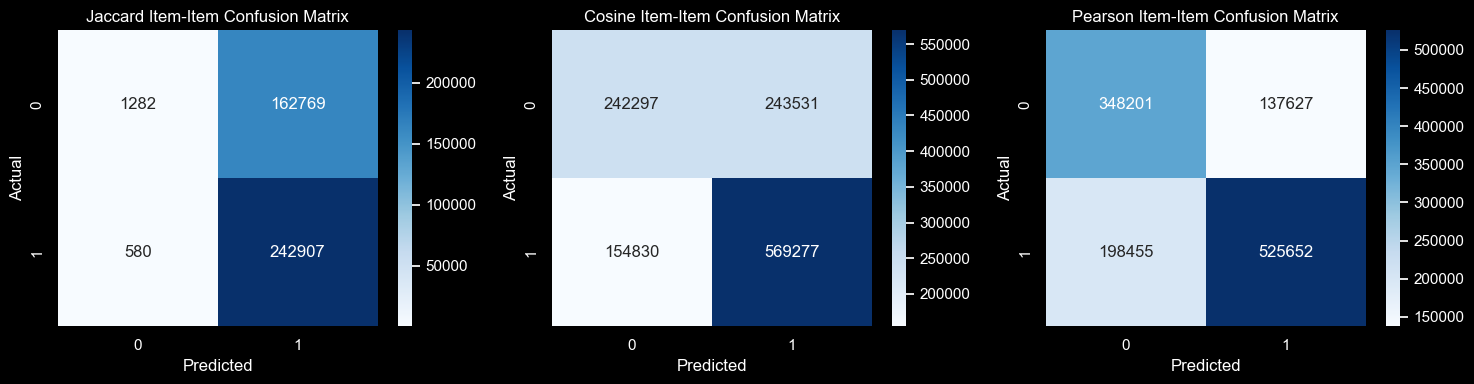

In [179]:
# -------- Confusion matrices --------
jaccard_item_cm = confusion_matrix(
    jaccard_item_predictions_df["true_relevant"],
    jaccard_item_predictions_df["pred_relevant"]
)

cosine_item_cm = confusion_matrix(
    cosine_item_predictions_df["true_relevant"],
    cosine_item_predictions_df["pred_relevant"]
)

pearson_item_cm = confusion_matrix(
    pearson_item_predictions_df["true_relevant"],
    pearson_item_predictions_df["pred_relevant"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(jaccard_item_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Jaccard Item-Item Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cosine_item_cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Cosine Item-Item Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(pearson_item_cm, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Pearson Item-Item Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### Resultados

In [180]:
summary_item_df = relevance_metrics_item_df.merge(
    rating_metrics_item_df,
    on="model",
    how="left"
)

display(summary_item_df)

,model,accuracy,precision,recall,f1,rmse,mae
0,Jaccard item-item,0.599181,0.598771,0.997618,0.748370,NaN,NaN
1,Cosine item-item,0.670758,0.700383,0.786178,0.740805,0.959334,0.727909
2,Pearson item-item,0.722231,0.792505,0.725931,0.757759,0.844413,0.639301


In [181]:
# Distribution of predicted relevance
print("Jaccard item-item predicted relevance distribution:")
print(jaccard_item_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())
print()

print("Cosine item-item predicted relevance distribution:")
print(cosine_item_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())
print()

print("Pearson item-item predicted relevance distribution:")
print(pearson_item_predictions_df["pred_relevant"].value_counts(normalize=True).sort_index())

Jaccard item-item predicted relevance distribution:
pred_relevant
0    0.004569
1    0.995431
Name: proportion, dtype: float64

Cosine item-item predicted relevance distribution:
pred_relevant
0    0.328222
1    0.671778
Name: proportion, dtype: float64

Pearson item-item predicted relevance distribution:
pred_relevant
0    0.451806
1    0.548194
Name: proportion, dtype: float64


In [182]:
# Save prediction outputs
predictions_dir = Path("./predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

jaccard_item_predictions_df.to_parquet(
    predictions_dir / f"jaccard_item_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

cosine_item_predictions_df.to_parquet(
    predictions_dir / f"cosine_item_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

pearson_item_predictions_df.to_parquet(
    predictions_dir / f"pearson_item_predictions_{WORKING_SAMPLE_KEY}.parquet",
    index=False,
    engine="fastparquet"
)

print("Item-item prediction files saved in:", predictions_dir.resolve())

Item-item prediction files saved in: /Users/bryan.guzman/Documents/Personal/Universidad/2026-01/Sistemas de Recomendación/SR-UNIANDES/Talleres/Taller 1/predictions


#### Resultados
En el enfoque ítem-ítem se observó nuevamente que Pearson supera a Cosine en predicción de rating, con RMSE = 0.8444 y MAE = 0.6393 frente a RMSE = 0.9593 y MAE = 0.7279 del modelo basado en coseno. Esto indica que la similitud de Pearson entre ítems logra capturar de manera más precisa la estructura de preferencias observada en el dataset.

En cuanto a la predicción de relevancia, Jaccard mantuvo el mismo patrón observado en el esquema usuario-usuario: un recall extremadamente alto acompañado de una fuerte sobrepredicción de la clase positiva, lo que limita su capacidad discriminativa. Cosine mostró un comportamiento balanceado, pero Pearson volvió a obtener los mejores resultados, con accuracy = 0.7222, precision = 0.7925 y F1 = 0.7578.

Al comparar directamente los enfoques usuario-usuario e ítem-ítem, se encontró que Cosine user-user fue ligeramente superior a Cosine item-item, mientras que Pearson item-item superó claramente a Pearson user-user en todas las métricas principales. Esto sugiere que, para este dataset, la estructura de similitud entre ítems resulta más estable y más informativa que la similitud entre usuarios, especialmente cuando se utiliza correlación de Pearson.

### 4.4. Varíe la estrategia de selección de vecinos por umbral de similitud y por número de vecinos. Revise cuál es el impacto al variar estos parámetros
### 4.5. Revise la estrategia de ponderación por significancia de McLaughlin’s [1] (McLaughlin’s significance weighting) y revise cuál es el impacto al variar los parámetros de esta estrategia

#### Setup Experimental

In [183]:
# Experimental setup for item-item sensitivity analysis
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score
)

K_VALUES_ITEM = [10, 40, 80]
SIM_THRESHOLDS_ITEM = [0.0, 0.2]
BETA_VALUES_ITEM = [10, 20, 40]

ITEM_TEST_EVAL_SAMPLE_SIZE = 20000
ITEM_RANDOM_STATE = 42

ITEM_RATING_THRESHOLD = 3.5
ITEM_RELEVANCE_THRESHOLD = 0.5

ITEM_BASE_K = 40
ITEM_BASE_MIN_SIM = 0.0
ITEM_BASE_MIN_K = 1

In [184]:
# Fixed evaluation subset for item-item experiments
ratings_binary_test_item_eval = ratings_binary_test.sample(
    n=min(ITEM_TEST_EVAL_SAMPLE_SIZE, len(ratings_binary_test)),
    random_state=ITEM_RANDOM_STATE
).copy()

ratings_explicit_test_item_eval = ratings_explicit_test[
    ratings_explicit_test.set_index(["userId", "movieId"]).index.isin(
        ratings_binary_test_item_eval.set_index(["userId", "movieId"]).index
    )
].copy()

test_set_surprise_item_eval = list(
    ratings_explicit_test_item_eval[["userId", "movieId", "rating"]]
    .itertuples(index=False, name=None)
)

print("Binary item-item eval sample:", ratings_binary_test_item_eval.shape)
print("Explicit item-item eval sample:", ratings_explicit_test_item_eval.shape)
print("Surprise item-item eval tuples:", len(test_set_surprise_item_eval))

Binary item-item eval sample: (20000, 4)
Explicit item-item eval sample: (20000, 4)
Surprise item-item eval tuples: 20000


In [185]:
# Auxiliary train structures for item-item significance weighting
user_items_all_train = (
    ratings_explicit_train
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

user_mean_rating_train = (
    ratings_explicit_train
    .groupby("userId")["rating"]
    .mean()
    .to_dict()
)

user_ratings_train = (
    ratings_explicit_train
    .groupby("userId")
    .apply(lambda x: dict(zip(x["movieId"], x["rating"])))
    .to_dict()
)

global_mean_rating_train = ratings_explicit_train["rating"].mean()

print("Users in user_items_all_train:", len(user_items_all_train))
print("Users in user_ratings_train:", len(user_ratings_train))
print("Global mean rating:", round(global_mean_rating_train, 4))

Users in user_items_all_train: 41547
Users in user_ratings_train: 41547
Global mean rating: 3.5373


#### Funciones de Evaluación

In [186]:
def jaccard_similarity(item_a_users, item_b_users):
    intersection = len(item_a_users & item_b_users)
    union = len(item_a_users | item_b_users)

    if union == 0:
        return 0.0

    return intersection / union

In [187]:
def significance_weight(common_count, beta):
    """
    McLaughlin-style significance weighting:
    w = min(1, common_count / beta)
    """
    return min(1.0, common_count / beta)

In [188]:
def predict_item_item_jaccard(
    user_id,
    movie_id,
    user_items_positive_train,
    item_users_positive_train,
    user_binary_feedback_train,
    user_relevance_mean_train,
    global_relevance_mean,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    user_history = user_items_positive_train.get(user_id, set()) - {movie_id}

    if len(user_history) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    target_item_users = item_users_positive_train.get(movie_id, set())

    scored_neighbors = []

    for neighbor_item in user_history:
        neighbor_users = item_users_positive_train.get(neighbor_item, set())
        sim = jaccard_similarity(target_item_users, neighbor_users)

        if sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(user_id, {}).get(neighbor_item, 0)
            scored_neighbors.append((neighbor_item, sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

In [190]:
def predict_item_item_jaccard(
    user_id,
    movie_id,
    user_items_positive_train,
    item_users_positive_train,
    user_binary_feedback_train,
    user_relevance_mean_train,
    global_relevance_mean,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    user_history = user_items_positive_train.get(user_id, set()) - {movie_id}

    if len(user_history) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    target_item_users = item_users_positive_train.get(movie_id, set())

    scored_neighbors = []

    for neighbor_item in user_history:
        neighbor_users = item_users_positive_train.get(neighbor_item, set())
        sim = jaccard_similarity(target_item_users, neighbor_users)

        if sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(user_id, {}).get(neighbor_item, 0)
            scored_neighbors.append((neighbor_item, sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

In [201]:
def predict_item_item_jaccard_with_significance(
    user_id,
    movie_id,
    user_items_positive_train,
    item_users_positive_train,
    user_binary_feedback_train,
    user_relevance_mean_train,
    global_relevance_mean,
    beta,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    user_history = user_items_positive_train.get(user_id, set()) - {movie_id}

    if len(user_history) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    target_item_users = item_users_positive_train.get(movie_id, set())
    scored_neighbors = []

    for neighbor_item in user_history:
        neighbor_users = item_users_positive_train.get(neighbor_item, set())

        base_sim = jaccard_similarity(target_item_users, neighbor_users)
        common_count = len(target_item_users & neighbor_users)
        adjusted_sim = base_sim * significance_weight(common_count, beta)

        if adjusted_sim > min_similarity:
            neighbor_label = user_binary_feedback_train.get(user_id, {}).get(neighbor_item, 0)
            scored_neighbors.append((neighbor_item, adjusted_sim, neighbor_label))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    numerator = sum(sim * label for _, sim, label in scored_neighbors)
    denominator = sum(sim for _, sim, _ in scored_neighbors)

    if denominator == 0:
        fallback_score = user_relevance_mean_train.get(user_id, global_relevance_mean)
        return fallback_score, int(fallback_score >= threshold), 0

    pred_score = numerator / denominator
    pred_relevant = int(pred_score >= threshold)

    return pred_score, pred_relevant, len(scored_neighbors)

In [193]:
def evaluate_item_jaccard_config(
    ratings_binary_test_eval,
    use_significance=False,
    beta=None,
    top_k=40,
    min_similarity=0.0,
    threshold=0.5
):
    y_true = []
    y_pred = []
    neighbors_used_list = []

    for row in ratings_binary_test_eval.itertuples(index=False):
        if use_significance:
            pred_score, pred_relevant, neighbors_used = predict_item_item_jaccard_with_significance(
                user_id=row.userId,
                movie_id=row.movieId,
                user_items_positive_train=user_items_positive_train,
                item_users_positive_train=item_users_positive_train,
                user_binary_feedback_train=user_binary_feedback_train,
                user_relevance_mean_train=user_relevance_mean_train,
                global_relevance_mean=global_relevance_mean,
                beta=beta,
                top_k=top_k,
                min_similarity=min_similarity,
                threshold=threshold
            )
        else:
            pred_score, pred_relevant, neighbors_used = predict_item_item_jaccard(
                user_id=row.userId,
                movie_id=row.movieId,
                user_items_positive_train=user_items_positive_train,
                item_users_positive_train=item_users_positive_train,
                user_binary_feedback_train=user_binary_feedback_train,
                user_relevance_mean_train=user_relevance_mean_train,
                global_relevance_mean=global_relevance_mean,
                top_k=top_k,
                min_similarity=min_similarity,
                threshold=threshold
            )

        y_true.append(row.relevant)
        y_pred.append(pred_relevant)
        neighbors_used_list.append(neighbors_used)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "avg_neighbors_used": float(np.mean(neighbors_used_list)),
        "pct_zero_neighbors": float(np.mean(np.array(neighbors_used_list) == 0))
    }

In [194]:
def evaluate_item_surprise_model(predictions, relevance_threshold=3.5):
    y_true_rating = np.array([pred.r_ui for pred in predictions], dtype=float)
    y_pred_rating = np.array([pred.est for pred in predictions], dtype=float)

    y_true_rel = (y_true_rating >= relevance_threshold).astype(int)
    y_pred_rel = (y_pred_rating >= relevance_threshold).astype(int)

    actual_k_values = [pred.details.get("actual_k", np.nan) for pred in predictions]
    actual_k_values = np.array(actual_k_values, dtype=float)

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true_rating, y_pred_rating))),
        "mae": float(mean_absolute_error(y_true_rating, y_pred_rating)),
        "f1": float(f1_score(y_true_rel, y_pred_rel, zero_division=0)),
        "avg_actual_k": float(np.nanmean(actual_k_values)),
        "pct_zero_neighbors": float(np.nanmean(actual_k_values == 0))
    }

In [202]:
def predict_surprise_item_with_significance(
    user_id,
    movie_id,
    algo,
    model_type,
    user_items_all_train,
    user_mean_rating_train,
    user_ratings_train,
    global_mean_rating_train,
    beta,
    top_k=40,
    min_similarity=0.0,
    rating_threshold=3.5
):
    """
    Manual item-item prediction using Surprise similarity matrix + significance weighting.
    model_type: 'cosine' or 'pearson'
    """
    user_history_ratings = user_ratings_train.get(user_id, {})

    if len(user_history_ratings) == 0:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    try:
        target_item_inner = algo.trainset.to_inner_iid(movie_id)
    except ValueError:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    scored_neighbors = []

    for neighbor_item, neighbor_rating in user_history_ratings.items():
        if neighbor_item == movie_id:
            continue

        try:
            neighbor_item_inner = algo.trainset.to_inner_iid(neighbor_item)
        except ValueError:
            continue

        base_sim = algo.sim[target_item_inner, neighbor_item_inner]

        common_count = len(
            item_users_positive_train.get(movie_id, set()) &
            item_users_positive_train.get(neighbor_item, set())
        )
        adjusted_sim = base_sim * significance_weight(common_count, beta)

        if adjusted_sim > min_similarity:
            scored_neighbors.append((neighbor_item, adjusted_sim, neighbor_rating))

    scored_neighbors = sorted(scored_neighbors, key=lambda x: x[1], reverse=True)[:top_k]

    if len(scored_neighbors) == 0:
        fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
        return fallback_rating, int(fallback_rating >= rating_threshold), 0

    if model_type == "cosine":
        numerator = sum(sim * rating for _, sim, rating in scored_neighbors)
        denominator = sum(sim for _, sim, _ in scored_neighbors)

        if denominator == 0:
            fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
            return fallback_rating, int(fallback_rating >= rating_threshold), 0

        pred_rating = numerator / denominator

    elif model_type == "pearson":
        user_mean = user_mean_rating_train.get(user_id, global_mean_rating_train)

        numerator = 0.0
        denominator = 0.0

        for neighbor_item, sim, neighbor_rating in scored_neighbors:
            # Approximate neighbor item mean from train ratings
            try:
                neighbor_item_inner = algo.trainset.to_inner_iid(neighbor_item)
                neighbor_item_ratings = algo.trainset.ir[neighbor_item_inner]
                neighbor_item_mean = np.mean([r for _, r in neighbor_item_ratings]) if len(neighbor_item_ratings) > 0 else global_mean_rating_train
            except Exception:
                neighbor_item_mean = global_mean_rating_train

            numerator += sim * (neighbor_rating - neighbor_item_mean)
            denominator += abs(sim)

        if denominator == 0:
            fallback_rating = user_mean_rating_train.get(user_id, global_mean_rating_train)
            return fallback_rating, int(fallback_rating >= rating_threshold), 0

        pred_rating = user_mean + (numerator / denominator)

    else:
        raise ValueError("model_type must be 'cosine' or 'pearson'")

    pred_relevant = int(pred_rating >= rating_threshold)
    return pred_rating, pred_relevant, len(scored_neighbors)

In [203]:
def evaluate_item_surprise_significance_config(
    algo,
    model_type,
    beta,
    top_k=40,
    min_similarity=0.0
):
    y_true_rating = []
    y_pred_rating = []
    y_true_rel = []
    y_pred_rel = []
    neighbors_used_list = []

    for row in ratings_explicit_test_item_eval.itertuples(index=False):
        pred_rating, pred_relevant, neighbors_used = predict_surprise_item_with_significance(
            user_id=row.userId,
            movie_id=row.movieId,
            algo=algo,
            model_type=model_type,
            user_items_all_train=user_items_all_train,
            user_mean_rating_train=user_mean_rating_train,
            user_ratings_train=user_ratings_train,
            global_mean_rating_train=global_mean_rating_train,
            beta=beta,
            top_k=top_k,
            min_similarity=min_similarity,
            rating_threshold=ITEM_RATING_THRESHOLD
        )

        y_true_rating.append(row.rating)
        y_pred_rating.append(pred_rating)
        y_true_rel.append(int(row.rating >= ITEM_RATING_THRESHOLD))
        y_pred_rel.append(pred_relevant)
        neighbors_used_list.append(neighbors_used)

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true_rating, y_pred_rating))),
        "mae": float(mean_absolute_error(y_true_rating, y_pred_rating)),
        "f1": float(f1_score(y_true_rel, y_pred_rel, zero_division=0)),
        "avg_neighbors_used": float(np.mean(neighbors_used_list)),
        "pct_zero_neighbors": float(np.mean(np.array(neighbors_used_list) == 0))
    }

#### Realizar experimentos de ajuste y significancia ítem por ítem.

In [197]:
# 3.1 Jaccard item-item over k
jaccard_item_k_results = []

for k in K_VALUES_ITEM:
    metrics = evaluate_item_jaccard_config(
        ratings_binary_test_eval=ratings_binary_test_item_eval,
        use_significance=False,
        beta=None,
        top_k=k,
        min_similarity=0.0,
        threshold=ITEM_RELEVANCE_THRESHOLD
    )

    jaccard_item_k_results.append({
        "model": "Jaccard item-item",
        "k": k,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "avg_neighbors_used": metrics["avg_neighbors_used"],
        "pct_zero_neighbors": metrics["pct_zero_neighbors"]
    })

jaccard_item_k_results_df = pd.DataFrame(jaccard_item_k_results)
display(jaccard_item_k_results_df)

,model,k,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard item-item,10,0.598086,0.998996,0.748222,3.37085,0.66065
1,Jaccard item-item,40,0.598086,0.998996,0.748222,12.47290,0.66065
2,Jaccard item-item,80,0.598086,0.998996,0.748222,22.38370,0.66065


In [198]:
# 3.2 Jaccard item-item over similarity threshold
jaccard_item_threshold_results = []

for sim_threshold in SIM_THRESHOLDS_ITEM:
    metrics = evaluate_item_jaccard_config(
        ratings_binary_test_eval=ratings_binary_test_item_eval,
        use_significance=False,
        beta=None,
        top_k=ITEM_BASE_K,
        min_similarity=sim_threshold,
        threshold=ITEM_RELEVANCE_THRESHOLD
    )

    jaccard_item_threshold_results.append({
        "model": "Jaccard item-item",
        "min_similarity": sim_threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "avg_neighbors_used": metrics["avg_neighbors_used"],
        "pct_zero_neighbors": metrics["pct_zero_neighbors"]
    })

jaccard_item_threshold_results_df = pd.DataFrame(jaccard_item_threshold_results)
display(jaccard_item_threshold_results_df)

,model,min_similarity,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard item-item,0.0,0.598086,0.998996,0.748222,12.4729,0.66065
1,Jaccard item-item,0.2,0.619158,0.957828,0.752127,0.7056,0.91195


In [199]:
# 3.3 Cosine and Pearson item-item over k
reader = Reader(rating_scale=(0.5, 5.0))
train_dataset = Dataset.load_from_df(
    ratings_explicit_train[["userId", "movieId", "rating"]],
    reader
)
trainset = train_dataset.build_full_trainset()

cosine_item_k_results = []
pearson_item_k_results = []

for k in K_VALUES_ITEM:
    cosine_item_algo = KNNBasic(
        k=k,
        min_k=ITEM_BASE_MIN_K,
        sim_options={"name": "cosine", "user_based": False},
        verbose=False
    )
    cosine_item_algo.fit(trainset)
    cosine_item_preds = cosine_item_algo.test(test_set_surprise_item_eval)
    cosine_metrics = evaluate_item_surprise_model(
        cosine_item_preds,
        relevance_threshold=ITEM_RATING_THRESHOLD
    )

    cosine_item_k_results.append({
        "model": "Cosine item-item",
        "k": k,
        "rmse": cosine_metrics["rmse"],
        "mae": cosine_metrics["mae"],
        "f1": cosine_metrics["f1"],
        "avg_actual_k": cosine_metrics["avg_actual_k"],
        "pct_zero_neighbors": cosine_metrics["pct_zero_neighbors"]
    })

    pearson_item_algo = KNNWithMeans(
        k=k,
        min_k=ITEM_BASE_MIN_K,
        sim_options={"name": "pearson", "user_based": False},
        verbose=False
    )
    pearson_item_algo.fit(trainset)
    pearson_item_preds = pearson_item_algo.test(test_set_surprise_item_eval)
    pearson_metrics = evaluate_item_surprise_model(
        pearson_item_preds,
        relevance_threshold=ITEM_RATING_THRESHOLD
    )

    pearson_item_k_results.append({
        "model": "Pearson item-item",
        "k": k,
        "rmse": pearson_metrics["rmse"],
        "mae": pearson_metrics["mae"],
        "f1": pearson_metrics["f1"],
        "avg_actual_k": pearson_metrics["avg_actual_k"],
        "pct_zero_neighbors": pearson_metrics["pct_zero_neighbors"]
    })

cosine_item_k_results_df = pd.DataFrame(cosine_item_k_results)
pearson_item_k_results_df = pd.DataFrame(pearson_item_k_results)

display(cosine_item_k_results_df)
display(pearson_item_k_results_df)

,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Cosine item-item,10,0.986307,0.748459,0.725441,9.999498,0.0
1,Cosine item-item,40,0.956811,0.726414,0.742358,38.813470,0.0
2,Cosine item-item,80,0.956072,0.727192,0.738727,72.823414,0.0


,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Pearson item-item,10,0.871620,0.660644,0.750998,9.960474,0.0032
1,Pearson item-item,40,0.840346,0.637249,0.758188,38.414243,0.0032
2,Pearson item-item,80,0.837931,0.635522,0.758000,71.578876,0.0032


In [204]:
# 3.4 Item-item significance weighting over beta
jaccard_item_significance_results = []
cosine_item_significance_results = []
pearson_item_significance_results = []

for beta in BETA_VALUES_ITEM:
    # Jaccard
    j_metrics = evaluate_item_jaccard_config(
        ratings_binary_test_eval=ratings_binary_test_item_eval,
        use_significance=True,
        beta=beta,
        top_k=ITEM_BASE_K,
        min_similarity=0.2,
        threshold=ITEM_RELEVANCE_THRESHOLD
    )

    jaccard_item_significance_results.append({
        "model": "Jaccard item-item",
        "beta": beta,
        "precision": j_metrics["precision"],
        "recall": j_metrics["recall"],
        "f1": j_metrics["f1"],
        "avg_neighbors_used": j_metrics["avg_neighbors_used"],
        "pct_zero_neighbors": j_metrics["pct_zero_neighbors"]
    })

    # Cosine
    c_metrics = evaluate_item_surprise_significance_config(
        algo=cosine_item_model,
        model_type="cosine",
        beta=beta,
        top_k=ITEM_BASE_K,
        min_similarity=0.0
    )

    cosine_item_significance_results.append({
        "model": "Cosine item-item",
        "beta": beta,
        "rmse": c_metrics["rmse"],
        "mae": c_metrics["mae"],
        "f1": c_metrics["f1"],
        "avg_neighbors_used": c_metrics["avg_neighbors_used"],
        "pct_zero_neighbors": c_metrics["pct_zero_neighbors"]
    })

    # Pearson
    p_metrics = evaluate_item_surprise_significance_config(
        algo=pearson_item_model,
        model_type="pearson",
        beta=beta,
        top_k=ITEM_BASE_K,
        min_similarity=0.0
    )

    pearson_item_significance_results.append({
        "model": "Pearson item-item",
        "beta": beta,
        "rmse": p_metrics["rmse"],
        "mae": p_metrics["mae"],
        "f1": p_metrics["f1"],
        "avg_neighbors_used": p_metrics["avg_neighbors_used"],
        "pct_zero_neighbors": p_metrics["pct_zero_neighbors"]
    })

jaccard_item_significance_results_df = pd.DataFrame(jaccard_item_significance_results)
cosine_item_significance_results_df = pd.DataFrame(cosine_item_significance_results)
pearson_item_significance_results_df = pd.DataFrame(pearson_item_significance_results)

display(jaccard_item_significance_results_df)
display(cosine_item_significance_results_df)
display(pearson_item_significance_results_df)

,model,beta,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard item-item,10,0.619055,0.957409,0.751922,0.69985,0.91395
1,Jaccard item-item,20,0.619048,0.957242,0.751865,0.69930,0.91440
2,Jaccard item-item,40,0.619094,0.957158,0.751873,0.69840,0.91495


,model,beta,rmse,mae,f1,avg_neighbors_used,pct_zero_neighbors
0,Cosine item-item,10,0.997733,0.749302,0.767387,38.14725,0.01355
1,Cosine item-item,20,1.019593,0.766253,0.764093,38.14725,0.01355
2,Cosine item-item,40,1.037771,0.781811,0.761449,38.14725,0.01355


,model,beta,rmse,mae,f1,avg_neighbors_used,pct_zero_neighbors
0,Pearson item-item,10,1.032468,0.790472,0.695701,37.8717,0.01445
1,Pearson item-item,20,1.031561,0.789416,0.696949,37.8717,0.01445
2,Pearson item-item,40,1.031136,0.788250,0.697703,37.8717,0.01445


#### Resultados

In [205]:
surprise_item_k_results_df = pd.concat(
    [cosine_item_k_results_df, pearson_item_k_results_df],
    ignore_index=True
)

item_significance_results_df = pd.concat(
    [
        jaccard_item_significance_results_df,
        cosine_item_significance_results_df,
        pearson_item_significance_results_df
    ],
    ignore_index=True
)

display(jaccard_item_k_results_df)
display(jaccard_item_threshold_results_df)
display(surprise_item_k_results_df)
display(item_significance_results_df)

,model,k,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard item-item,10,0.598086,0.998996,0.748222,3.37085,0.66065
1,Jaccard item-item,40,0.598086,0.998996,0.748222,12.47290,0.66065
2,Jaccard item-item,80,0.598086,0.998996,0.748222,22.38370,0.66065


,model,min_similarity,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors
0,Jaccard item-item,0.0,0.598086,0.998996,0.748222,12.4729,0.66065
1,Jaccard item-item,0.2,0.619158,0.957828,0.752127,0.7056,0.91195


,model,k,rmse,mae,f1,avg_actual_k,pct_zero_neighbors
0,Cosine item-item,10,0.986307,0.748459,0.725441,9.999498,0.0000
1,Cosine item-item,40,0.956811,0.726414,0.742358,38.813470,0.0000
2,Cosine item-item,80,0.956072,0.727192,0.738727,72.823414,0.0000
3,Pearson item-item,10,0.871620,0.660644,0.750998,9.960474,0.0032
4,Pearson item-item,40,0.840346,0.637249,0.758188,38.414243,0.0032
5,Pearson item-item,80,0.837931,0.635522,0.758000,71.578876,0.0032


,model,beta,precision,recall,f1,avg_neighbors_used,pct_zero_neighbors,rmse,mae
0,Jaccard item-item,10,0.619055,0.957409,0.751922,0.69985,0.91395,NaN,NaN
1,Jaccard item-item,20,0.619048,0.957242,0.751865,0.69930,0.91440,NaN,NaN
2,Jaccard item-item,40,0.619094,0.957158,0.751873,0.69840,0.91495,NaN,NaN
3,Cosine item-item,10,NaN,NaN,0.767387,38.14725,0.01355,0.997733,0.749302
4,Cosine item-item,20,NaN,NaN,0.764093,38.14725,0.01355,1.019593,0.766253
5,Cosine item-item,40,NaN,NaN,0.761449,38.14725,0.01355,1.037771,0.781811
6,Pearson item-item,10,NaN,NaN,0.695701,37.87170,0.01445,1.032468,0.790472
7,Pearson item-item,20,NaN,NaN,0.696949,37.87170,0.01445,1.031561,0.789416
8,Pearson item-item,40,NaN,NaN,0.697703,37.87170,0.01445,1.031136,0.788250


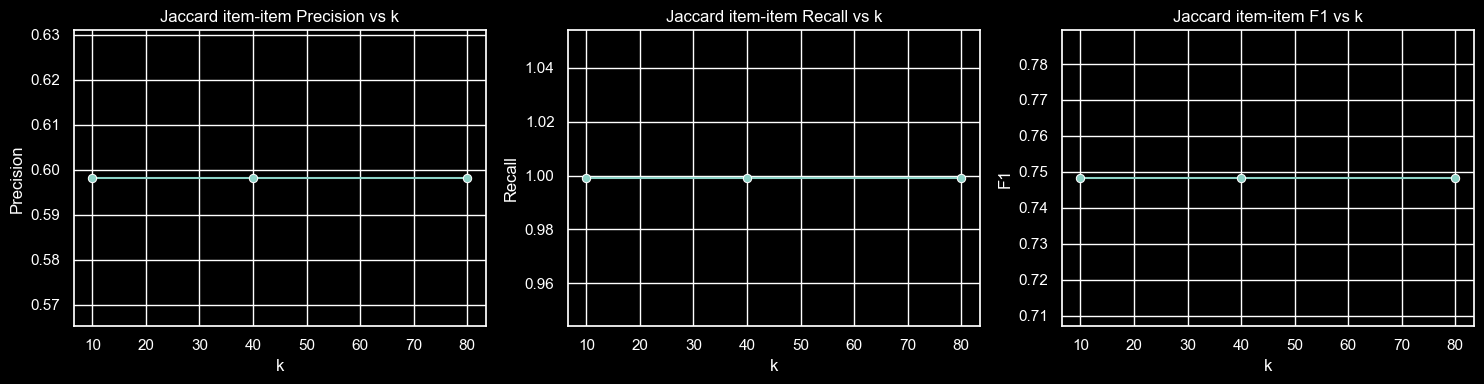

In [206]:
# Plot 1: Jaccard item-item vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_item_k_results_df, x="k", y="precision", marker="o", ax=axes[0])
axes[0].set_title("Jaccard item-item Precision vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Precision")

sns.lineplot(data=jaccard_item_k_results_df, x="k", y="recall", marker="o", ax=axes[1])
axes[1].set_title("Jaccard item-item Recall vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Recall")

sns.lineplot(data=jaccard_item_k_results_df, x="k", y="f1", marker="o", ax=axes[2])
axes[2].set_title("Jaccard item-item F1 vs k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

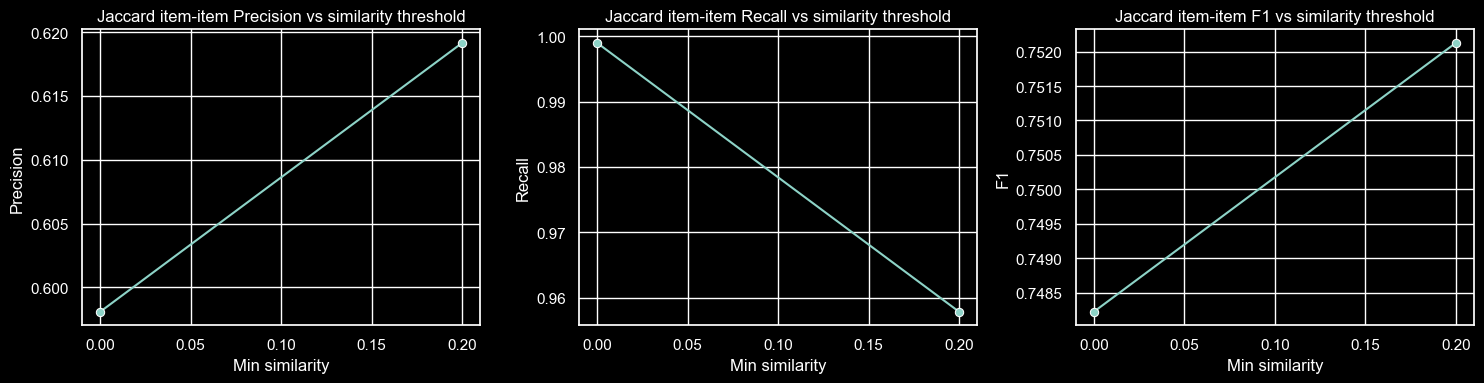

In [207]:
# Plot 2: Jaccard item-item vs min_similarity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_item_threshold_results_df, x="min_similarity", y="precision", marker="o", ax=axes[0])
axes[0].set_title("Jaccard item-item Precision vs similarity threshold")
axes[0].set_xlabel("Min similarity")
axes[0].set_ylabel("Precision")

sns.lineplot(data=jaccard_item_threshold_results_df, x="min_similarity", y="recall", marker="o", ax=axes[1])
axes[1].set_title("Jaccard item-item Recall vs similarity threshold")
axes[1].set_xlabel("Min similarity")
axes[1].set_ylabel("Recall")

sns.lineplot(data=jaccard_item_threshold_results_df, x="min_similarity", y="f1", marker="o", ax=axes[2])
axes[2].set_title("Jaccard item-item F1 vs similarity threshold")
axes[2].set_xlabel("Min similarity")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

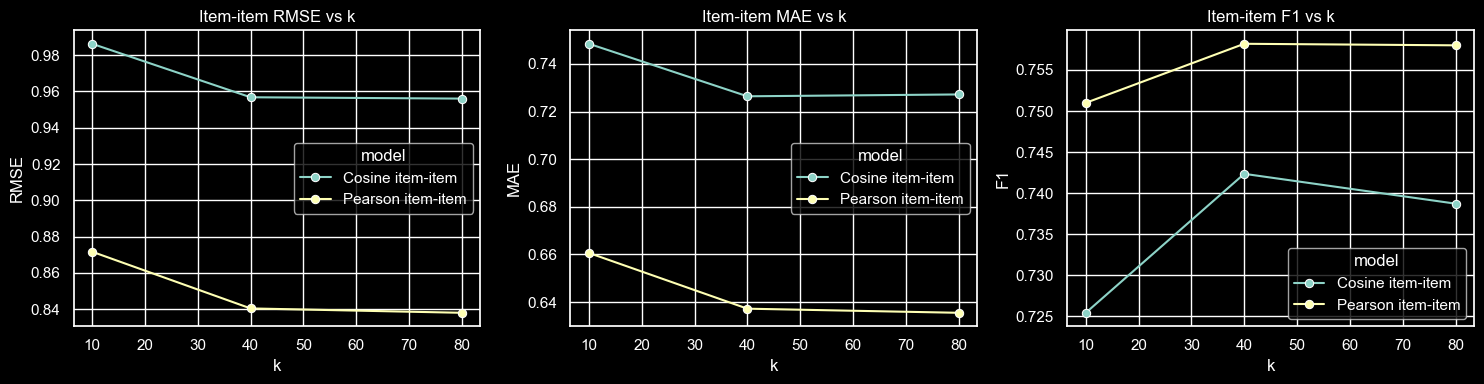

In [208]:
# Plot 3: Cosine and Pearson item-item vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=surprise_item_k_results_df, x="k", y="rmse", hue="model", marker="o", ax=axes[0])
axes[0].set_title("Item-item RMSE vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("RMSE")

sns.lineplot(data=surprise_item_k_results_df, x="k", y="mae", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Item-item MAE vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("MAE")

sns.lineplot(data=surprise_item_k_results_df, x="k", y="f1", hue="model", marker="o", ax=axes[2])
axes[2].set_title("Item-item F1 vs k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

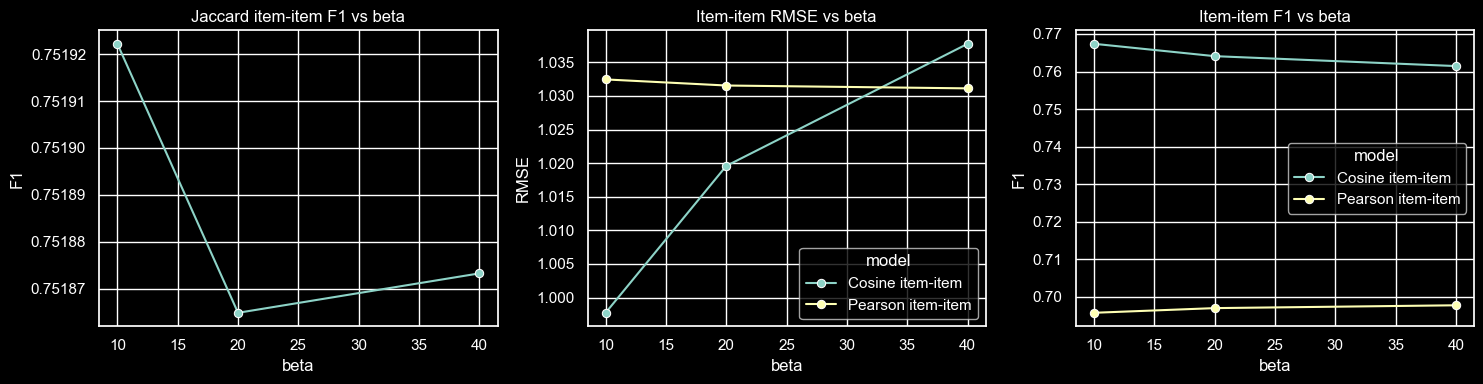

In [209]:
# Plot 4: Item-item significance weighting vs beta
surprise_item_significance_results_df = pd.concat(
    [cosine_item_significance_results_df, pearson_item_significance_results_df],
    ignore_index=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=jaccard_item_significance_results_df, x="beta", y="f1", marker="o", ax=axes[0])
axes[0].set_title("Jaccard item-item F1 vs beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("F1")

sns.lineplot(data=surprise_item_significance_results_df, x="beta", y="rmse", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Item-item RMSE vs beta")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("RMSE")

sns.lineplot(data=surprise_item_significance_results_df, x="beta", y="f1", hue="model", marker="o", ax=axes[2])
axes[2].set_title("Item-item F1 vs beta")
axes[2].set_xlabel("beta")
axes[2].set_ylabel("F1")

plt.tight_layout()
plt.show()

#### Análisis
En el análisis de sensibilidad del enfoque ítem-ítem se observó que el modelo Jaccard, al igual que en el caso usuario-usuario, fue prácticamente insensible al número de vecinos. Variar k entre 10 y 80 no modificó precision, recall ni F1-score, aunque sí incrementó el número promedio de vecinos utilizados. En contraste, el umbral mínimo de similitud tuvo un efecto observable: al pasar de 0.0 a 0.2 mejoró ligeramente precision y F1, pero a costa de una reducción importante en la cobertura, reflejada en una alta tasa de casos sin vecinos.

En los modelos basados en coseno y Pearson, el número de vecinos sí tuvo un impacto claro. En ambos casos, aumentar k de 10 a 40 produjo mejoras sustanciales en RMSE, MAE y F1-score, mientras que el salto de 40 a 80 generó beneficios marginales o incluso ligeras pérdidas en F1. Esto sugiere que k = 40 constituye un punto de equilibrio razonable entre calidad predictiva y costo computacional.

En cuanto a la estrategia de McLaughlin’s significance weighting, sus efectos fueron heterogéneos. En Jaccard item-item el impacto fue mínimo, manteniendo prácticamente constantes las métricas para todos los valores de beta. En Cosine item-item, la ponderación por significancia mejoró el F1-score, pero empeoró RMSE y MAE, indicando un trade-off entre clasificación de relevancia y precisión numérica del rating. Finalmente, en Pearson item-item la significance weighting deterioró claramente todas las métricas, lo que sugiere que en este caso la configuración base ya era suficientemente robusta y que la penalización adicional eliminó información útil del vecindario.

En conjunto, estos resultados muestran que el mejor modelo ítem-ítem sigue siendo Pearson con un valor de k cercano a 40 y sin significance weighting, mientras que Jaccard conserva limitaciones de discriminación similares a las observadas en el enfoque usuario-usuario.

## 5. Conclusión

In [210]:
# --- Select best User-User models automatically ---

best_jaccard_user = jaccard_threshold_results_df.sort_values(
    ["f1", "precision"], ascending=[False, False]
).iloc[0]

best_cosine_user = pd.concat(
    [
        cosine_k_results_df.assign(source="k_tuning", beta=np.nan),
        cosine_significance_results_df.assign(source="significance", k=np.nan)
    ],
    ignore_index=True
).sort_values(["rmse", "mae", "f1"], ascending=[True, True, False]).iloc[0]

best_pearson_user = pd.concat(
    [
        pearson_k_results_df.assign(source="k_tuning", beta=np.nan),
        pearson_significance_results_df.assign(source="significance", k=np.nan)
    ],
    ignore_index=True
).sort_values(["rmse", "mae", "f1"], ascending=[True, True, False]).iloc[0]


# --- Select best Item-Item models automatically ---

best_jaccard_item = pd.concat(
    [
        jaccard_item_threshold_results_df.assign(source="threshold_tuning", beta=np.nan, k=ITEM_BASE_K),
        jaccard_item_significance_results_df.assign(source="significance", min_similarity=0.2, k=ITEM_BASE_K)
    ],
    ignore_index=True
).sort_values(["f1", "precision"], ascending=[False, False]).iloc[0]

best_cosine_item = pd.concat(
    [
        cosine_item_k_results_df.assign(source="k_tuning", beta=np.nan),
        cosine_item_significance_results_df.assign(source="significance", k=ITEM_BASE_K)
    ],
    ignore_index=True
).sort_values(["rmse", "mae", "f1"], ascending=[True, True, False]).iloc[0]

best_pearson_item = pd.concat(
    [
        pearson_item_k_results_df.assign(source="k_tuning", beta=np.nan),
        pearson_item_significance_results_df.assign(source="significance", k=ITEM_BASE_K)
    ],
    ignore_index=True
).sort_values(["rmse", "mae", "f1"], ascending=[True, True, False]).iloc[0]


# --- Build final summary table dynamically ---

final_models_df = pd.DataFrame([
    {
        "family": "User-User",
        "model": "Jaccard",
        "source": best_jaccard_user.get("source", "threshold_tuning"),
        "k": best_jaccard_user.get("k", np.nan),
        "min_similarity": best_jaccard_user.get("min_similarity", np.nan),
        "beta": best_jaccard_user.get("beta", np.nan),
        "precision": best_jaccard_user.get("precision", np.nan),
        "recall": best_jaccard_user.get("recall", np.nan),
        "f1": best_jaccard_user.get("f1", np.nan),
        "rmse": np.nan,
        "mae": np.nan
    },
    {
        "family": "User-User",
        "model": "Cosine",
        "source": best_cosine_user.get("source", np.nan),
        "k": best_cosine_user.get("k", np.nan),
        "min_similarity": best_cosine_user.get("min_similarity", np.nan),
        "beta": best_cosine_user.get("beta", np.nan),
        "precision": np.nan,
        "recall": np.nan,
        "f1": best_cosine_user.get("f1", np.nan),
        "rmse": best_cosine_user.get("rmse", np.nan),
        "mae": best_cosine_user.get("mae", np.nan)
    },
    {
        "family": "User-User",
        "model": "Pearson",
        "source": best_pearson_user.get("source", np.nan),
        "k": best_pearson_user.get("k", np.nan),
        "min_similarity": best_pearson_user.get("min_similarity", np.nan),
        "beta": best_pearson_user.get("beta", np.nan),
        "precision": np.nan,
        "recall": np.nan,
        "f1": best_pearson_user.get("f1", np.nan),
        "rmse": best_pearson_user.get("rmse", np.nan),
        "mae": best_pearson_user.get("mae", np.nan)
    },
    {
        "family": "Item-Item",
        "model": "Jaccard",
        "source": best_jaccard_item.get("source", np.nan),
        "k": best_jaccard_item.get("k", np.nan),
        "min_similarity": best_jaccard_item.get("min_similarity", np.nan),
        "beta": best_jaccard_item.get("beta", np.nan),
        "precision": best_jaccard_item.get("precision", np.nan),
        "recall": best_jaccard_item.get("recall", np.nan),
        "f1": best_jaccard_item.get("f1", np.nan),
        "rmse": np.nan,
        "mae": np.nan
    },
    {
        "family": "Item-Item",
        "model": "Cosine",
        "source": best_cosine_item.get("source", np.nan),
        "k": best_cosine_item.get("k", np.nan),
        "min_similarity": best_cosine_item.get("min_similarity", np.nan),
        "beta": best_cosine_item.get("beta", np.nan),
        "precision": np.nan,
        "recall": np.nan,
        "f1": best_cosine_item.get("f1", np.nan),
        "rmse": best_cosine_item.get("rmse", np.nan),
        "mae": best_cosine_item.get("mae", np.nan)
    },
    {
        "family": "Item-Item",
        "model": "Pearson",
        "source": best_pearson_item.get("source", np.nan),
        "k": best_pearson_item.get("k", np.nan),
        "min_similarity": best_pearson_item.get("min_similarity", np.nan),
        "beta": best_pearson_item.get("beta", np.nan),
        "precision": np.nan,
        "recall": np.nan,
        "f1": best_pearson_item.get("f1", np.nan),
        "rmse": best_pearson_item.get("rmse", np.nan),
        "mae": best_pearson_item.get("mae", np.nan)
    }
])

display(final_models_df.sort_values(["family", "model"]).reset_index(drop=True))

,family,model,source,k,min_similarity,beta,precision,recall,f1,rmse,mae
0,Item-Item,Cosine,k_tuning,80.0,NaN,NaN,NaN,NaN,0.738727,0.956072,0.727192
1,Item-Item,Jaccard,threshold_tuning,40.0,0.2,NaN,0.619158,0.957828,0.752127,NaN,NaN
2,Item-Item,Pearson,k_tuning,80.0,NaN,NaN,NaN,NaN,0.758000,0.837931,0.635522
3,User-User,Cosine,k_tuning,80.0,NaN,NaN,NaN,NaN,0.749560,0.938810,0.717817
4,User-User,Jaccard,threshold_tuning,NaN,0.2,NaN,0.649245,0.901288,0.754781,NaN,NaN
5,User-User,Pearson,significance,NaN,NaN,20.0,NaN,NaN,0.752656,0.869406,0.662051


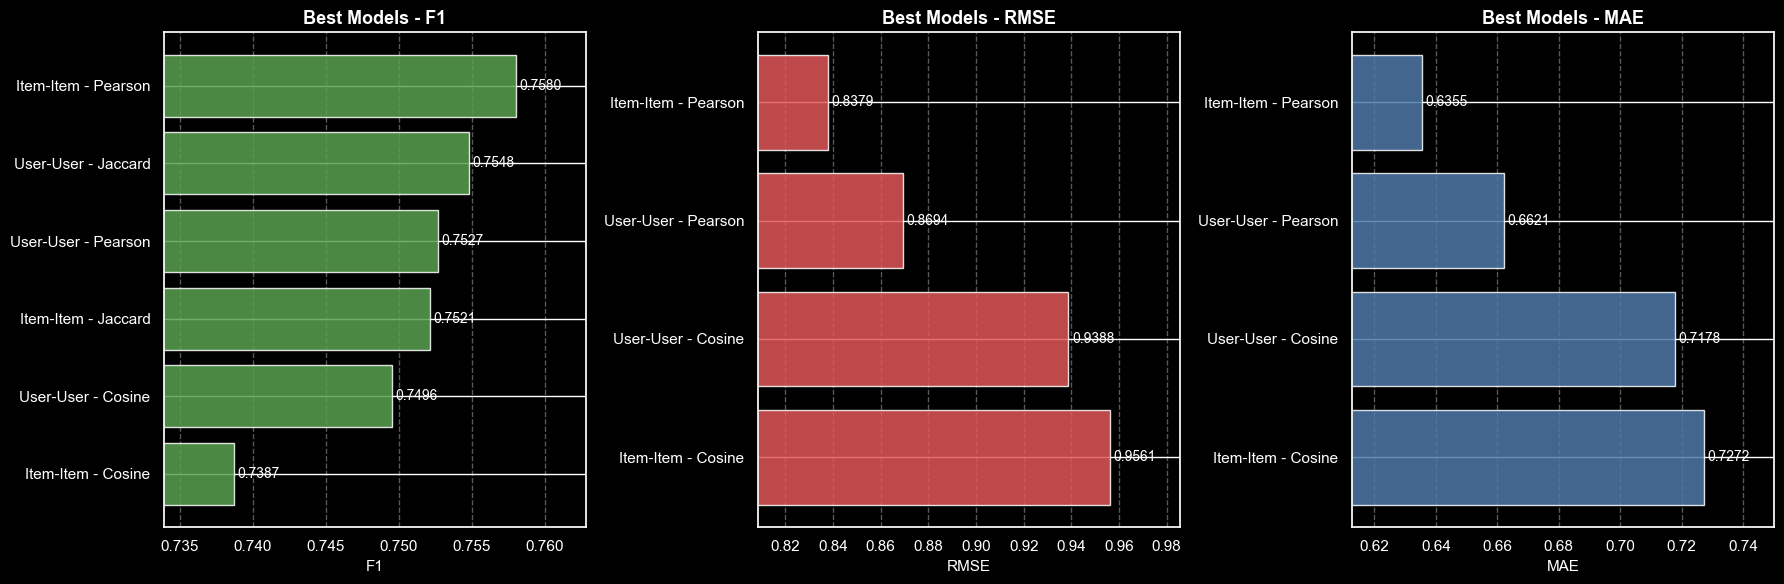

In [213]:
plot_df = final_models_df.copy()
plot_df["label"] = plot_df["family"] + " - " + plot_df["model"]

def plot_metric(ax, df, metric, title, ascending, color="#4C78A8"):
    data = df.dropna(subset=[metric]).sort_values(metric, ascending=ascending).copy()

    labels = data["label"]
    values = data[metric]

    bars = ax.barh(labels, values, color=color, alpha=0.85)

    # Mejor valor arriba
    ax.invert_yaxis()

    # Etiquetas numéricas al final de cada barra
    vmin, vmax = values.min(), values.max()
    spread = vmax - vmin

    # Padding dinámico para que se vean mejor diferencias y etiquetas
    if spread == 0:
        pad = vmax * 0.05 if vmax != 0 else 0.05
    else:
        pad = spread * 0.25

    x_left = max(0, vmin - pad)
    x_right = vmax + pad
    ax.set_xlim(x_left, x_right)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + pad * 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            ha="left",
            fontsize=10
        )

    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel(metric.upper(), fontsize=11)
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

# Figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# F1: más alto es mejor
plot_metric(
    axes[0],
    plot_df,
    metric="f1",
    title="Best Models - F1",
    ascending=False,
    color="#59A14F"
)

# RMSE: más bajo es mejor
plot_metric(
    axes[1],
    plot_df,
    metric="rmse",
    title="Best Models - RMSE",
    ascending=True,
    color="#E15759"
)

# MAE: más bajo es mejor
plot_metric(
    axes[2],
    plot_df,
    metric="mae",
    title="Best Models - MAE",
    ascending=True,
    color="#4E79A7"
)

plt.tight_layout()
plt.show()